### Imports

In [1]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
from matplotlib.ticker import LogLocator

plt.style.use('/Users/koichiro/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
#plt.style.use('/Users/koichiromacmini/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
#plt.style.use('/Users/koichiromacstudio/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')

# Transition Edge Sensor

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  983  |   0   | +9.7024e+42 | 1.00e+00 | 4.84e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   | 1966  |   1   | +9.7023e+42 | 7.00e+00 | 4.97e+35 | 3.10e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   | 2949  |   2   | +9.7023e+42 | 4.90e+01 | 5.64e+35 | 2.63e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   | 3932  |   3   | +9.7022e+42 | 3.43e+02 | 6.60e+35 | 2.97e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 4915  |   5   | +9.7019e+42 | 6.85e+02 | 6.17e+35 | 8.63e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 5898  |  11   | +9.7011e+42 | 4.11e+03 | 6.46e+35 | 1.57e+01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 6881  |  34   | +9.6946e+42 | 2.74e+04 | 6.50e+35 | 3.75e+01 | 1.00e+00 |  1.00e-01   

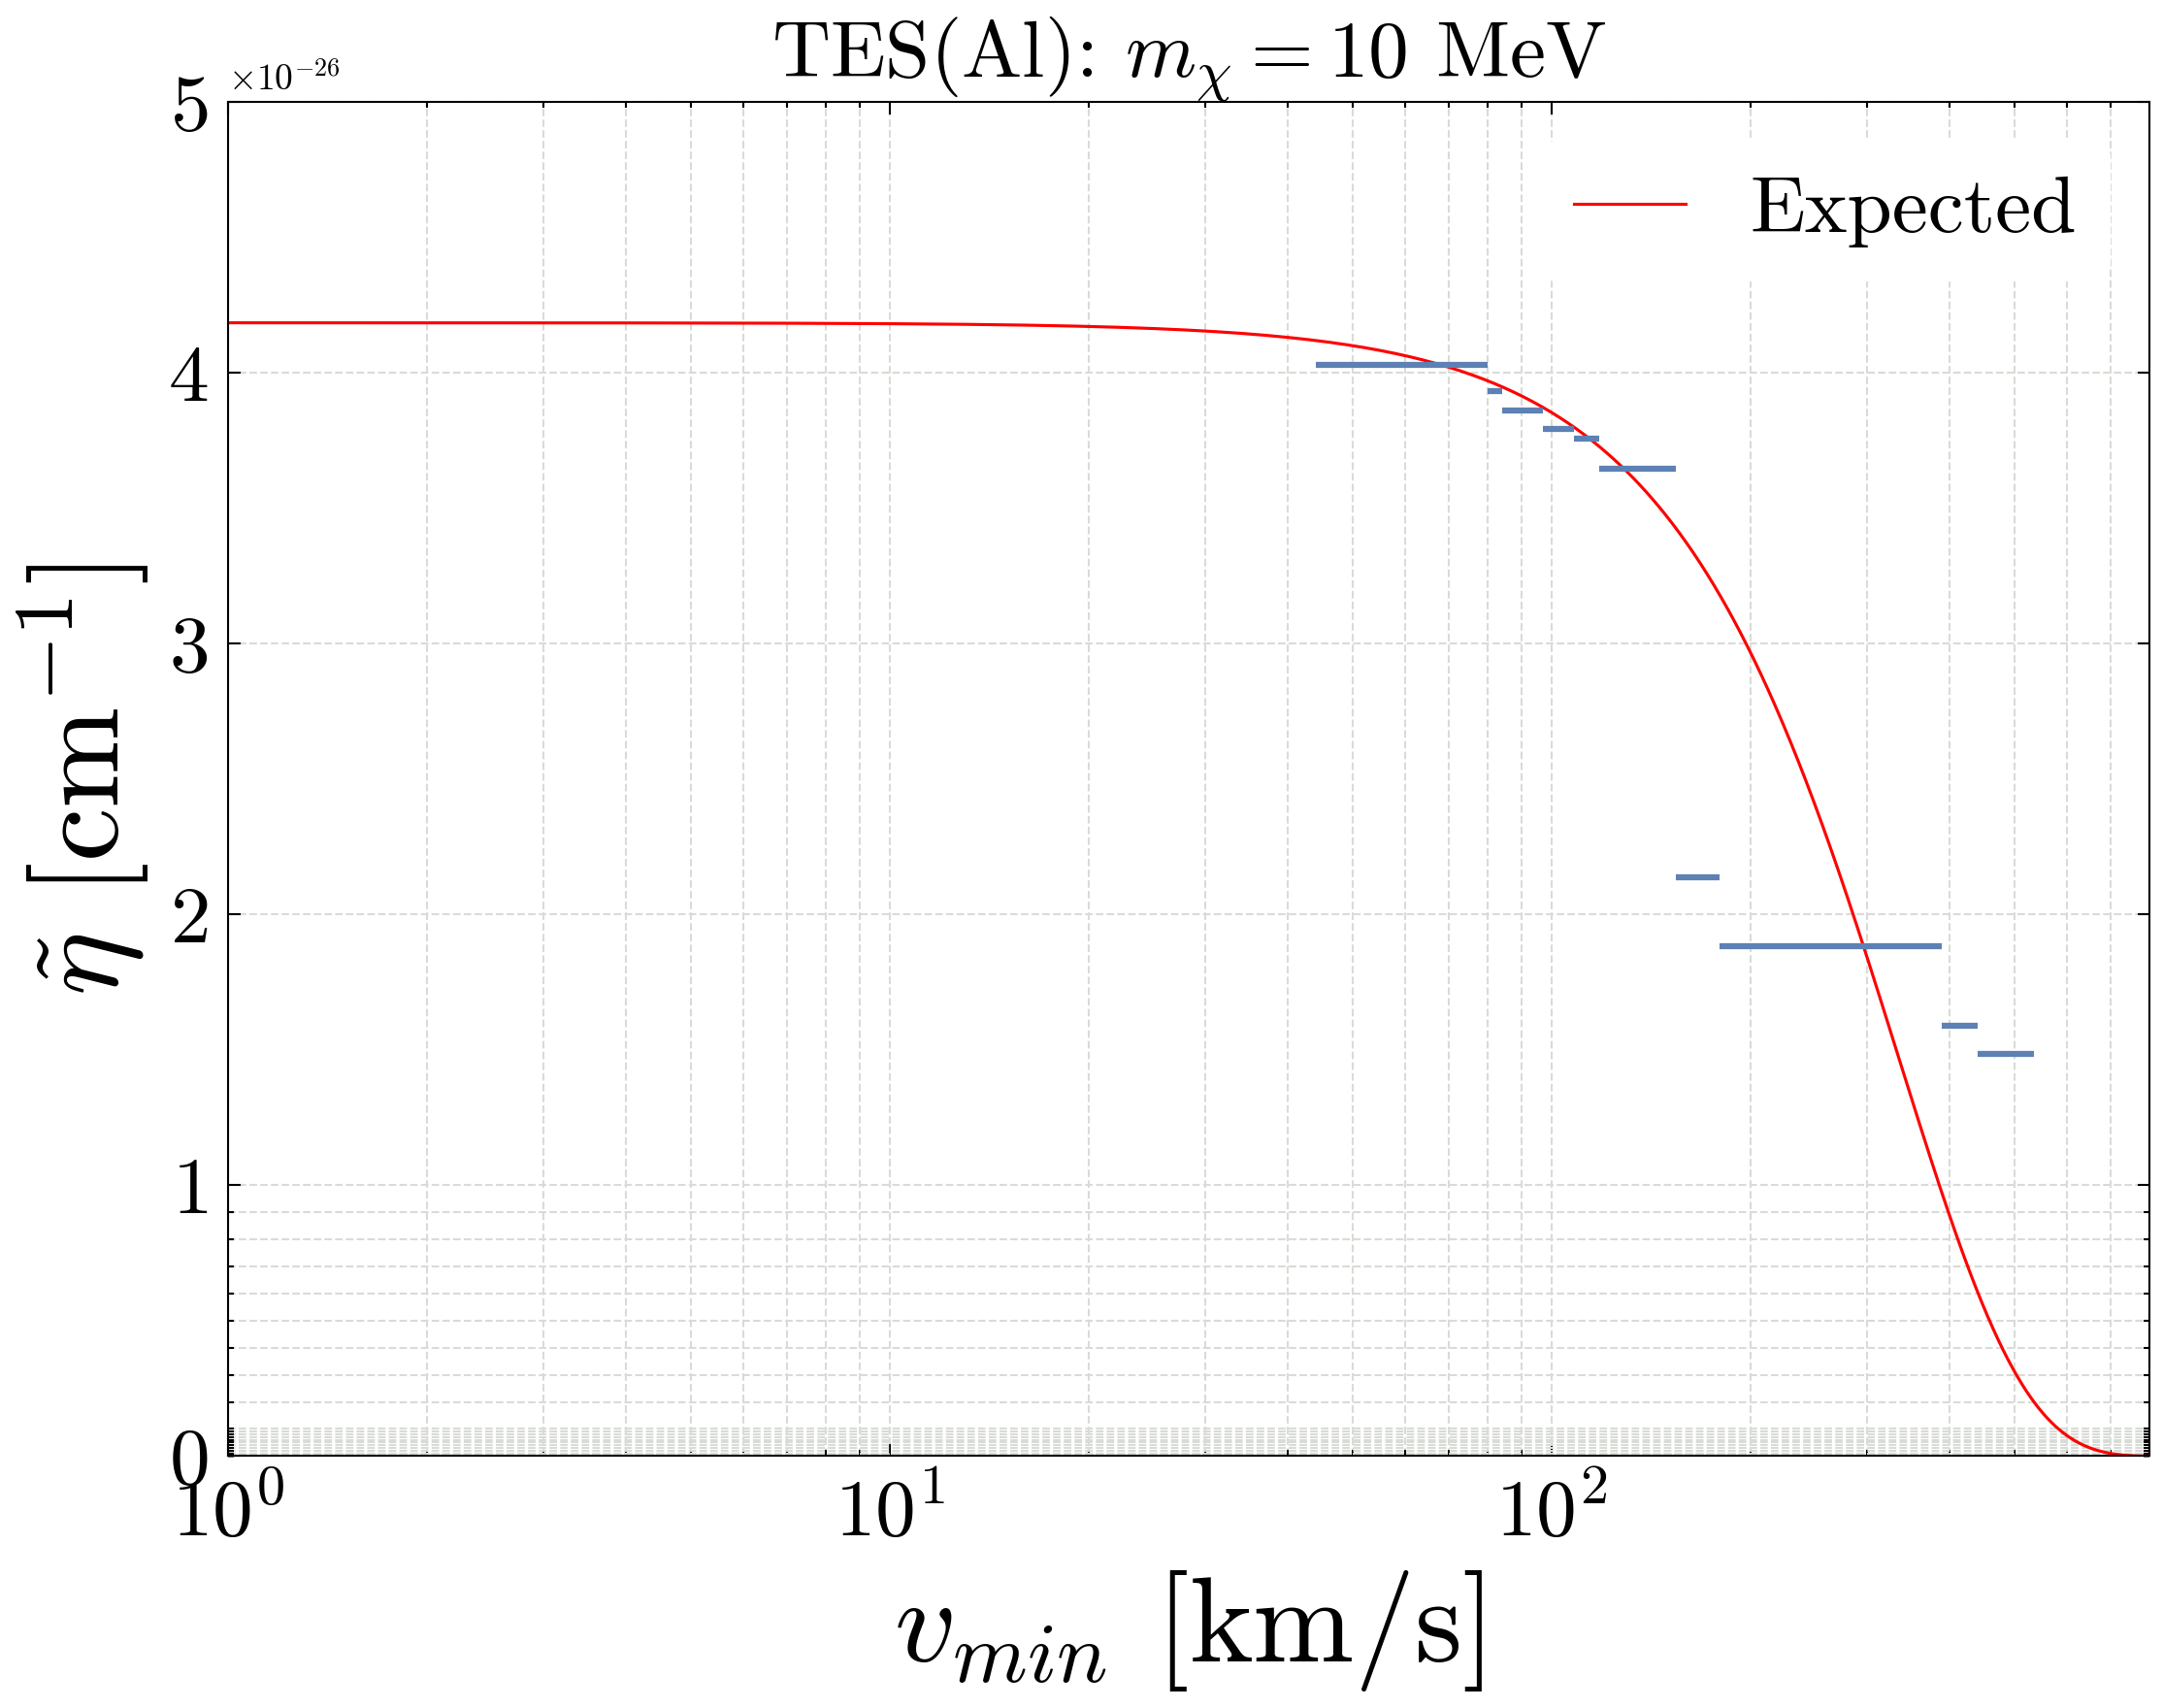

In [56]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'Al', mass = '1', q= '0', cons1 = 1, cons2 = 9e35)#cons1 = 1, cons2 = 9e35, cons1 = 1, cons2 = 8e35, cons1 = 1, cons2 = 5e35, cons1 = 2e33, cons2 = 4e62
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    plt.ylim(0, 5e-26)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 10$ MeV', fontsize=20)

    plt.savefig('results/TES_10MeV_q=0_SHM.pdf')

In [20]:
result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm

array([2.91965959e-25, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93161968e-26, 3.93161968e-26,
       3.93161968e-26, 3.93161968e-26, 3.93160226e-26, 3.93160226e-26,
       3.93160226e-26, 3.93160226e-26, 3.93160226e-26, 3.93160226e-26,
       3.93160226e-26, 3.93160226e-26, 3.93160226e-26, 3.93160226e-26,
       3.93160226e-26, 3.93160226e-26, 3.93160226e-26, 3.93160226e-26,
       3.93160226e-26, 3.93160226e-26, 3.93160226e-26, 3.93160226e-26,
       3.93160226e-26, 3.93160226e-26, 3.93160226e-26, 3.93160226e-26,
       3.93148426e-26, 3.93148426e-26, 3.93148426e-26, 3.93148426e-26,
      

In [15]:
analysis_none.cm

50505.0505050505

In [16]:
analysis_none.CRmat@analysis_none.fig1Solid[44:535]/analysis_none.cm

array([ 335517.43317617, 1359848.94709085, 2225526.76888683,
       3036969.72002062, 3829193.77548887])

In [39]:
analysis_none.CRmat@analysis_none.fig1Solid[44:535]/analysis_none.cm

array([ 342474.71684136, 1386533.39922638, 2265665.82141482,
       3086272.6539624 , 3884729.98390825])

In [123]:
np.savetxt('results/events/events_TESSHM10MeV.csv', 3.32323e-6 * np.array([ 342474.71684136, 1386533.39922638, 2265665.82141482, 3086272.6539624 , 3884729.98390825]))

In [57]:
TESSHM10MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm

np.savetxt('results/data/TESSHM10MeV.csv', TESSHM10MeV)

In [42]:
TESSHM10MeV

array([7.24044418e-25, 4.20323308e-26, 4.20317424e-26, 4.20315326e-26,
       4.20314220e-26, 4.20313590e-26, 4.20313211e-26, 4.20312925e-26,
       4.20312722e-26, 4.20312569e-26, 4.20312449e-26, 4.20312354e-26,
       4.20312275e-26, 4.20312214e-26, 4.20312165e-26, 4.20312123e-26,
       4.20312089e-26, 4.20312058e-26, 4.20312031e-26, 4.20312006e-26,
       4.20311983e-26, 4.20311962e-26, 4.20311943e-26, 4.20311924e-26,
       4.20311906e-26, 4.20311889e-26, 4.20311872e-26, 4.20311856e-26,
       4.20311840e-26, 4.20311823e-26, 4.20311807e-26, 4.20311789e-26,
       4.20311771e-26, 4.20311751e-26, 4.20311730e-26, 4.20311709e-26,
       4.20311691e-26, 4.20311673e-26, 4.20311655e-26, 4.20311607e-26,
       4.20311541e-26, 4.20311503e-26, 4.20311474e-26, 4.20311438e-26,
       4.20311393e-26, 4.20311336e-26, 4.20311266e-26, 4.20311197e-26,
       4.20311159e-26, 4.20311125e-26, 4.20311094e-26, 4.20311066e-26,
       4.20311043e-26, 4.20311026e-26, 4.20311008e-26, 4.08327069e-26,
      

In [247]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([10244.4817846 , 20615.42881826, 30360.78729068, 40357.14611788,
       49485.64288508])

In [120]:
3.32323e-6 * np.array([10244.4817846 , 20615.42881826, 30360.78729068, 40357.14611788,
       49485.64288508])

array([0.03404477, 0.06850981, 0.10089588, 0.13411608, 0.16445217])

In [248]:
analysis_none.Ratebin2

array([10254.60733379, 20597.39824856, 30372.08459187, 40353.27561638,
       49486.15146687])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  233  |   0   | +1.1314e+41 | 1.00e+00 | 7.02e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  466  |   1   | +1.1313e+41 | 7.00e+00 | 7.14e+35 | 6.74e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  699  |   2   | +1.1311e+41 | 4.90e+01 | 7.91e+35 | 5.67e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  932  |   3   | +1.1304e+41 | 1.42e+02 | 7.61e+35 | 2.61e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 1165  |   4   | +1.1299e+41 | 1.42e+02 | 6.99e+35 | 1.99e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 1398  |   5   | +1.1294e+41 | 1.42e+02 | 6.38e+35 | 1.57e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 1631  |   6   | +1.1283e+41 | 2.02e+02 | 5.88e+35 | 1.09e-01 | 1.00e+00 |  1.00e-01   

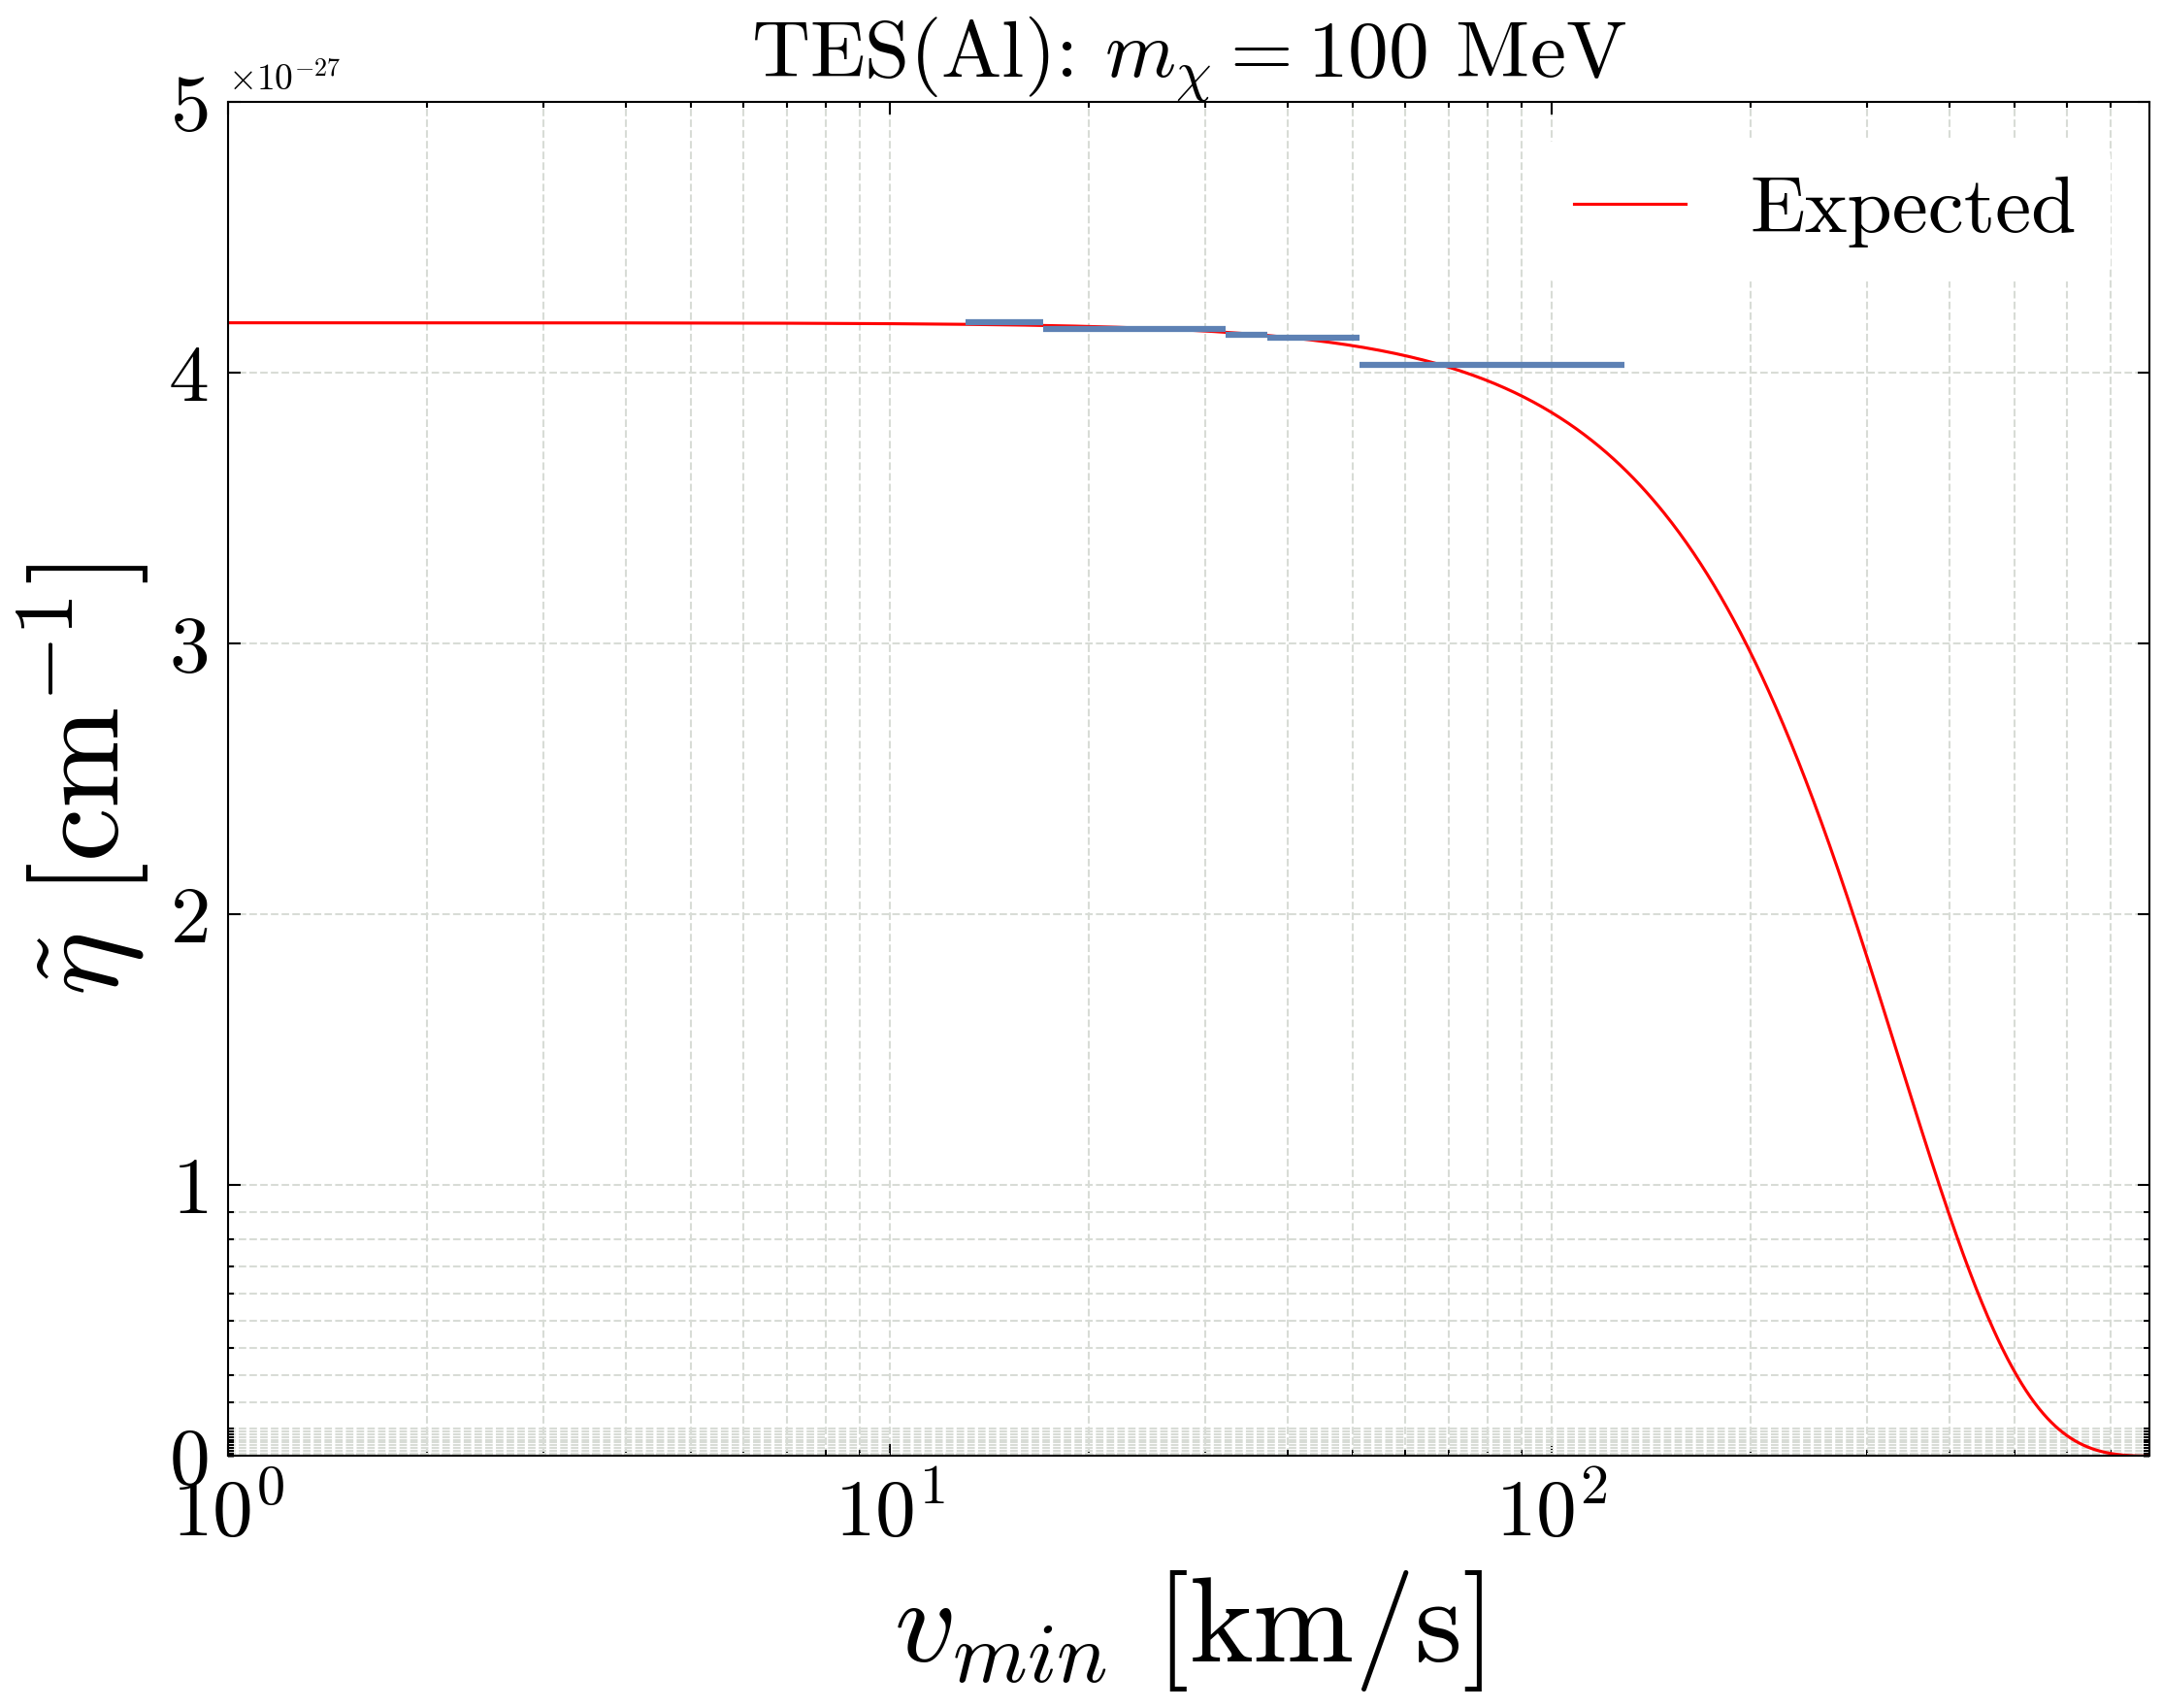

In [58]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'Al', mass = '2', q= '0', cons1 = 1, cons2 = 9e34)#, cons1 = 2e33, cons2 = 4e62
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    plt.ylim(0, 5e-27)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 100$ MeV', fontsize=20)
    #plt.xscale('linear')
    #plt.xlim(40, 113)
    plt.savefig('results/TES_100MeV_q=0_SHM.pdf')

In [47]:
analysis_none.CRmat@analysis_none.fig1Solid[13:129]/analysis_none.cm

array([ 36475.81029529, 154826.98882365, 256272.74366474, 355729.26549119,
       454103.01735778])

In [122]:
np.savetxt('results/events/events_TESSHM100MeV.csv', 3.32323e-6 * np.array([10244.4817846 , 20615.42881826, 30360.78729068, 40357.14611788, 49485.64288508]))

In [49]:
TESSHM100MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESSHM100MeV.csv', TESSHM100MeV)

In [50]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 37647.05639665, 159762.32855397, 264335.38918639, 366717.19981191,
       467798.66819508])

In [104]:
analysis_none.Ratebin2

array([ 37647.05639665, 159762.32855397, 264335.38918639, 366717.19981191,
       467798.66819508])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  249  |   0   | +1.0979e+39 | 1.00e+00 | 6.33e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  498  |   1   | +1.0951e+39 | 7.00e+00 | 6.42e+35 | 1.43e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  747  |   2   | +1.0795e+39 | 4.90e+01 | 6.64e+35 | 1.10e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  996  |   3   | +1.0360e+39 | 9.51e+01 | 5.82e+35 | 2.61e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 1245  |   4   | +9.2623e+38 | 2.31e+02 | 5.57e+35 | 1.39e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 1494  |   5   | +5.4089e+38 | 8.98e+02 | 4.28e+35 | 6.32e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 1743  |  129  | +2.4492e+38 | 9.54e+02 | 2.67e+35 | 7.04e-03 | 1.00e+00 |  1.00e-01   

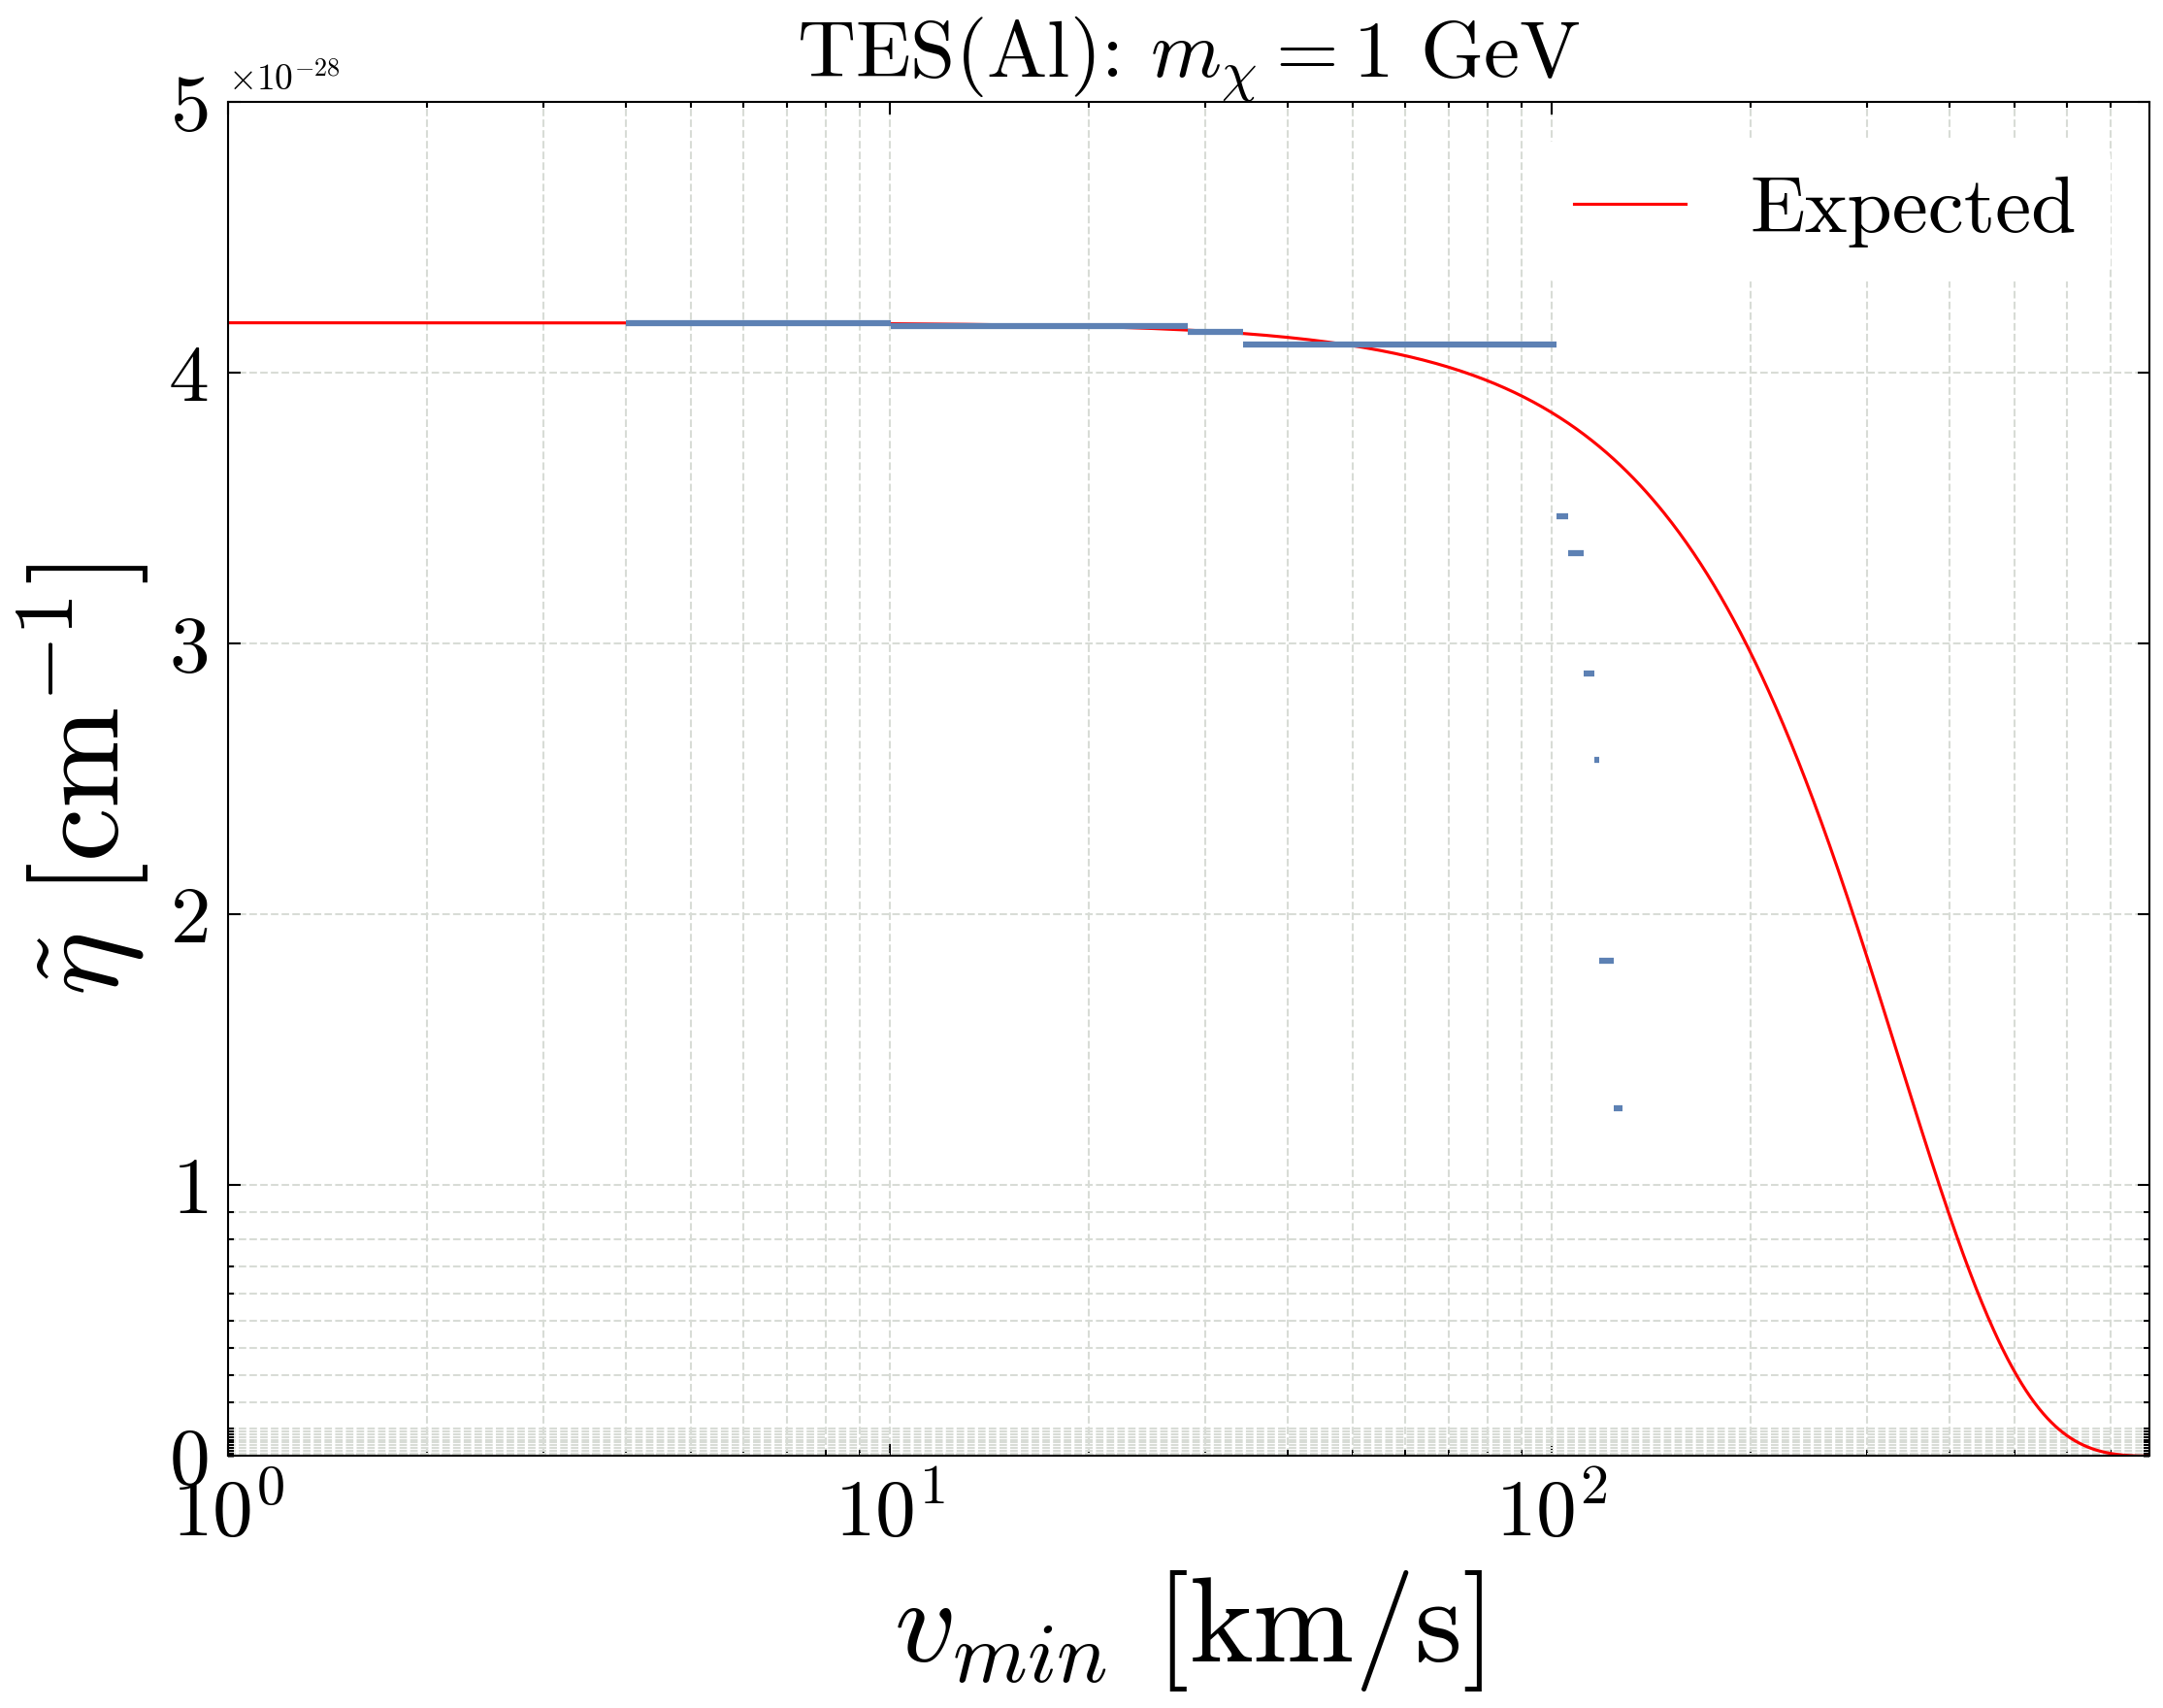

In [39]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'Al', mass = '3', q= '0', cons1 = 1, cons2 = 9e33)#, cons1 = 2e33, cons2 = 4e62
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    plt.ylim(0, 5e-28)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 1$ GeV', fontsize=20)
    plt.savefig('results/TES_1GeV_q=0_SHM.pdf')

In [38]:
analysis_none.CRmat@analysis_none.fig1Solid[4:128]/analysis_none.cm

array([ 3833.80665558, 15074.2182263 , 25459.39151964, 35529.49544492,
       45468.98396129])

In [124]:
np.savetxt('results/events/events_TESSHM1000MeV.csv', 3.32323e-6 * np.array([ 3958.06437708, 15560.42051035, 26272.61917238, 36647.8470621 , 46871.63724004]))

In [42]:
result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm

array([4.18552862e-28, 4.18552832e-28, 4.18552818e-28, 4.18552812e-28,
       4.18552809e-28, 4.18552806e-28, 4.17431849e-28, 4.17431840e-28,
       4.17431835e-28, 4.17431831e-28, 4.17431828e-28, 4.17431828e-28,
       4.17431827e-28, 4.17431825e-28, 4.17431824e-28, 4.17431823e-28,
       4.17431821e-28, 4.17431820e-28, 4.17431819e-28, 4.17431817e-28,
       4.17431816e-28, 4.17431813e-28, 4.17431811e-28, 4.17431798e-28,
       4.15060094e-28, 4.15059376e-28, 4.15059339e-28, 4.15059334e-28,
       4.15059333e-28, 4.15055303e-28, 4.10678062e-28, 4.10678054e-28,
       4.10678047e-28, 4.10678044e-28, 4.10678041e-28, 4.10678040e-28,
       4.10678039e-28, 4.10678038e-28, 4.10678036e-28, 4.10678035e-28,
       4.10678034e-28, 4.10678033e-28, 4.10678032e-28, 4.10678030e-28,
       4.10678029e-28, 4.10678027e-28, 4.10678023e-28, 4.10678020e-28,
       4.10678016e-28, 4.10678012e-28, 4.10678008e-28, 4.10678003e-28,
       4.10677997e-28, 4.10677992e-28, 4.10677986e-28, 4.10677980e-28,
      

In [43]:
TESSHM1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESSHM1000MeV.csv', TESSHM1000MeV)

In [99]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 3958.06437708, 15560.42051035, 26272.61917238, 36647.8470621 ,
       46871.63724004])

In [256]:
analysis_none.Ratebin2

array([122.61854345, 247.40821836, 374.93442571, 498.34186822,
       622.19695885])

### Disk

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  171  |   0   | +7.8374e+32 | 1.00e+00 | 5.40e+31 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  342  |   1   | +6.9860e+32 | 7.00e+00 | 4.52e+31 | 2.25e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  513  |  38   | +1.2117e+32 | 4.84e+01 | 5.33e+30 | 1.96e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   4   |  684  |  94   | +6.6649e+31 | 4.84e+01 | 2.22e+30 | 2.32e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   5   |  855  |  179  | +3.4025e+31 | 4.84e+01 | 1.03e+30 | 2.16e-01 | 1.00e+00 |  1.00e-01   |   1   |
|   6   | 1026  |  264  | +2.4301e+31 | 4.84e+01 | 6.15e+29 | 1.61e-01 | 1.00e+00 |  1.00e-01   |   1   |
|   7   | 1197  |  349  | +1.9331e+31 | 4.84e+01 | 3.98e+29 | 1.21e-01 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  226  | 42750 | 6209  | +4.4138e+10 | 2.18e+00 | 7.06e+04 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   2   |
|  227  | 42921 | 6219  | +4.4138e+10 | 1.05e+00 | 7.06e+04 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   2   |
|  228  | 43092 | 6224  | +4.4138e+10 | 1.05e+00 | 1.07e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   2   |
|  229  | 43263 | 6228  | +4.4138e+10 | 1.05e+00 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  230  | 43605 | 6232  | +4.4138e+10 | 1.05e-01 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  231  | 43947 | 6236  | +4.4138e+10 | 1.05e-02 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  232  | 44289 | 6240  | +4.4138e+10 | 1.05e-03 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  233  | 44631 | 6244  | +4.4138e+10 | 1.05e-04 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  234  | 44973 | 6248  | +4.4138e+10 | 1.05e-05 | 1.03e+05 | 0.00e+00 | 9.84e+21 |  2.00e-02   |   4   |
|  235  | 45315 | 6252  | +4.4138e+10 | 1.05e-

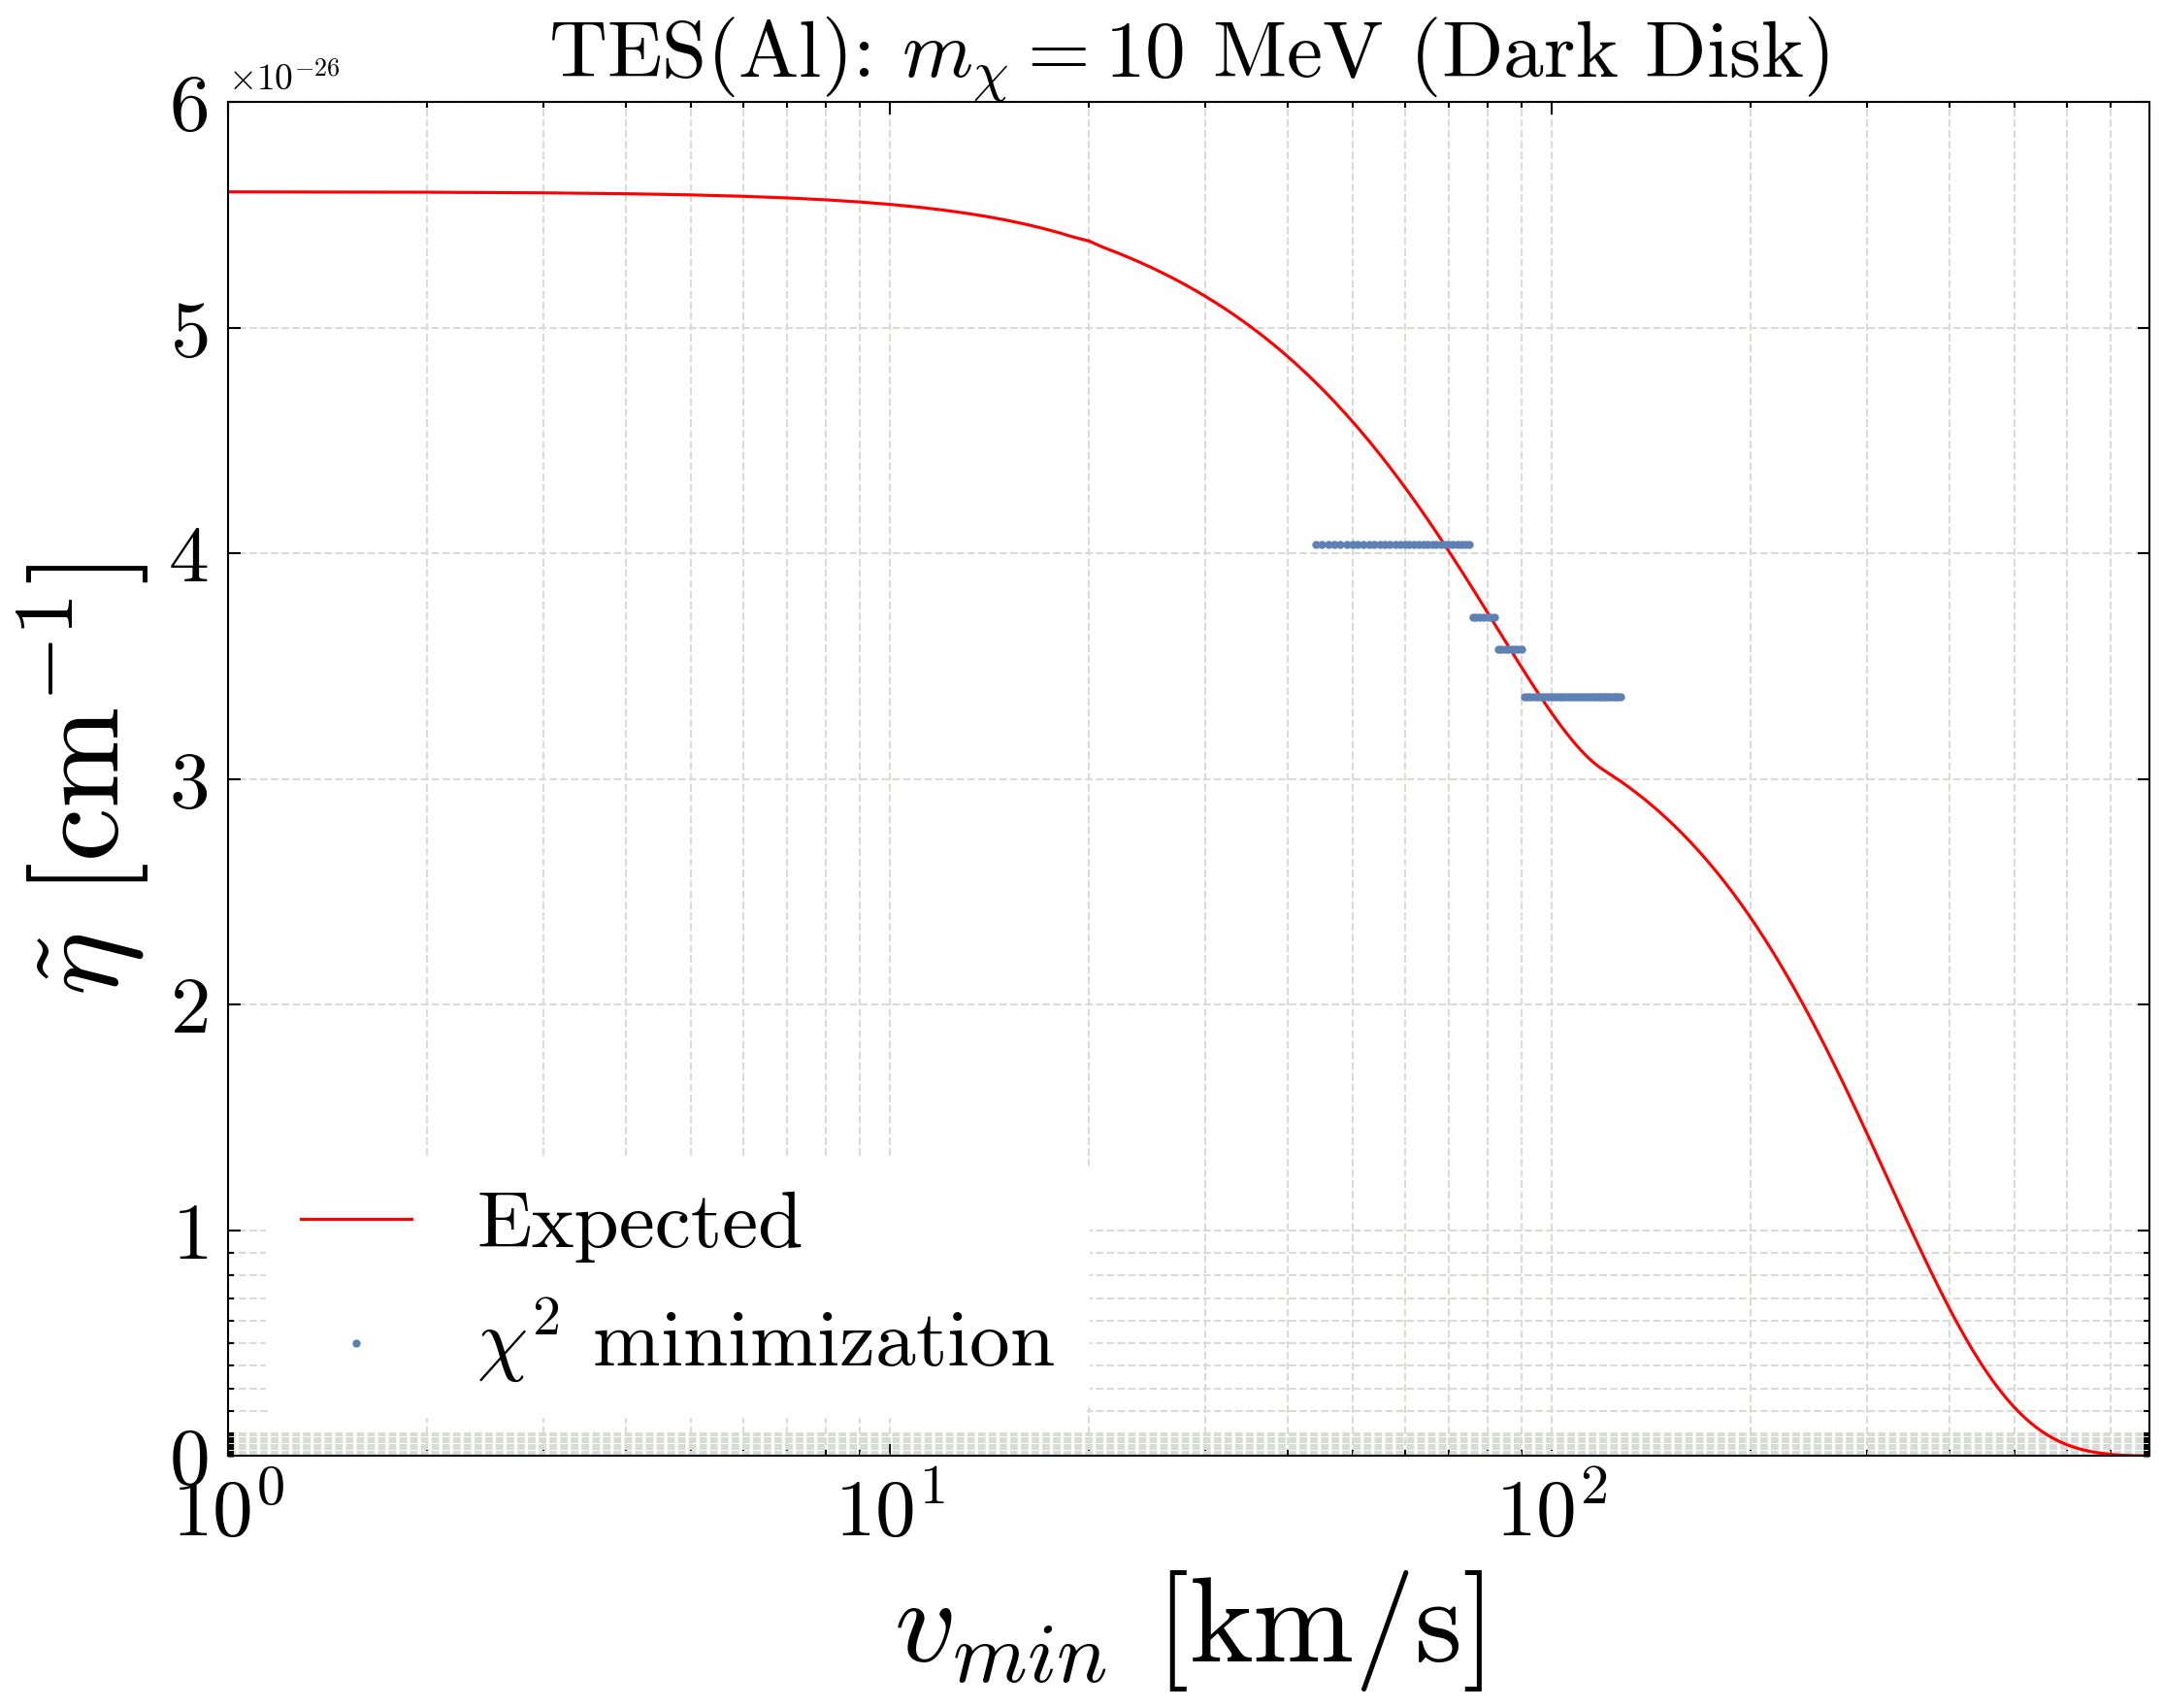

In [12]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'Al', mass = '1', q= '0', cons1 = 6e-5, cons2 = 1e10)#5.8e-3, cons1 = 3.7e-13, cons2 = 1e5
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-26)
    plt.ylim(0, 6e-26)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 10$ MeV (Dark Disk)', fontsize=20)
    plt.savefig('results/TES_10MeV_q=0_Disk.pdf')

In [258]:
analysis_none.CRmat@analysis_none.fig1Solid[42:127]/analysis_none.cm

array([ 9970.31024671, 19399.76829149, 27684.23663693, 35670.43535531,
       42536.05982049])

In [13]:
TESDisk10MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESDisk10MeV.csv', TESDisk10MeV)

In [259]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 9970.31024671, 19399.76829149, 27684.23663693, 35670.43535531,
       42536.05982049])

In [260]:
analysis_none.Ratebin2

array([ 9970.31024671, 19399.76829149, 27684.23663693, 35670.43535531,
       42536.05982049])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  201  |   0   | +2.2110e+23 | 1.00e+00 | 3.17e+14 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  402  |   1   | +2.2110e+23 | 7.00e+00 | 3.25e+14 | 1.62e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  603  |   2   | +2.2110e+23 | 4.90e+01 | 3.53e+14 | 1.48e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  804  |   4   | +2.2110e+23 | 1.18e+02 | 3.21e+14 | 5.01e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 1005  |  85   | +2.2110e+23 | 1.18e+02 | 2.96e+14 | 4.05e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   6   | 1206  |  169  | +2.2110e+23 | 1.18e+02 | 2.70e+14 | 3.04e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   7   | 1407  |  171  | +2.2110e+23 | 1.78e+02 | 2.59e+14 | 7.31e-01 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  780  |167031 | 9073  | +1.0393e+19 | 1.00e-07 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  781  |167232 | 9075  | +1.0393e+19 | 1.00e-08 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  782  |167433 | 9076  | +1.0393e+19 | 5.00e-09 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  783  |167634 | 9077  | +1.0393e+19 | 2.50e-09 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  784  |167835 | 9078  | +1.0393e+19 | 1.25e-09 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  785  |168036 | 9079  | +1.0393e+19 | 6.25e-10 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   2   |
|  786  |168237 | 9079  | +1.0393e+19 | 1.00e+00 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  3.20e-05   |   0   |
|  787  |168639 | 9083  | +1.0393e+19 | 1.00e-01 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  3.20e-05   |   2   |
|  788  |169041 | 9087  | +1.0393e+19 | 1.00e-02 | 4.38e+01 | 0.00e+00 | 1.00e+00 |  3.20e-05   |   2   |
|  789  |169443 | 9091  | +1.0393e+19 | 1.00e-

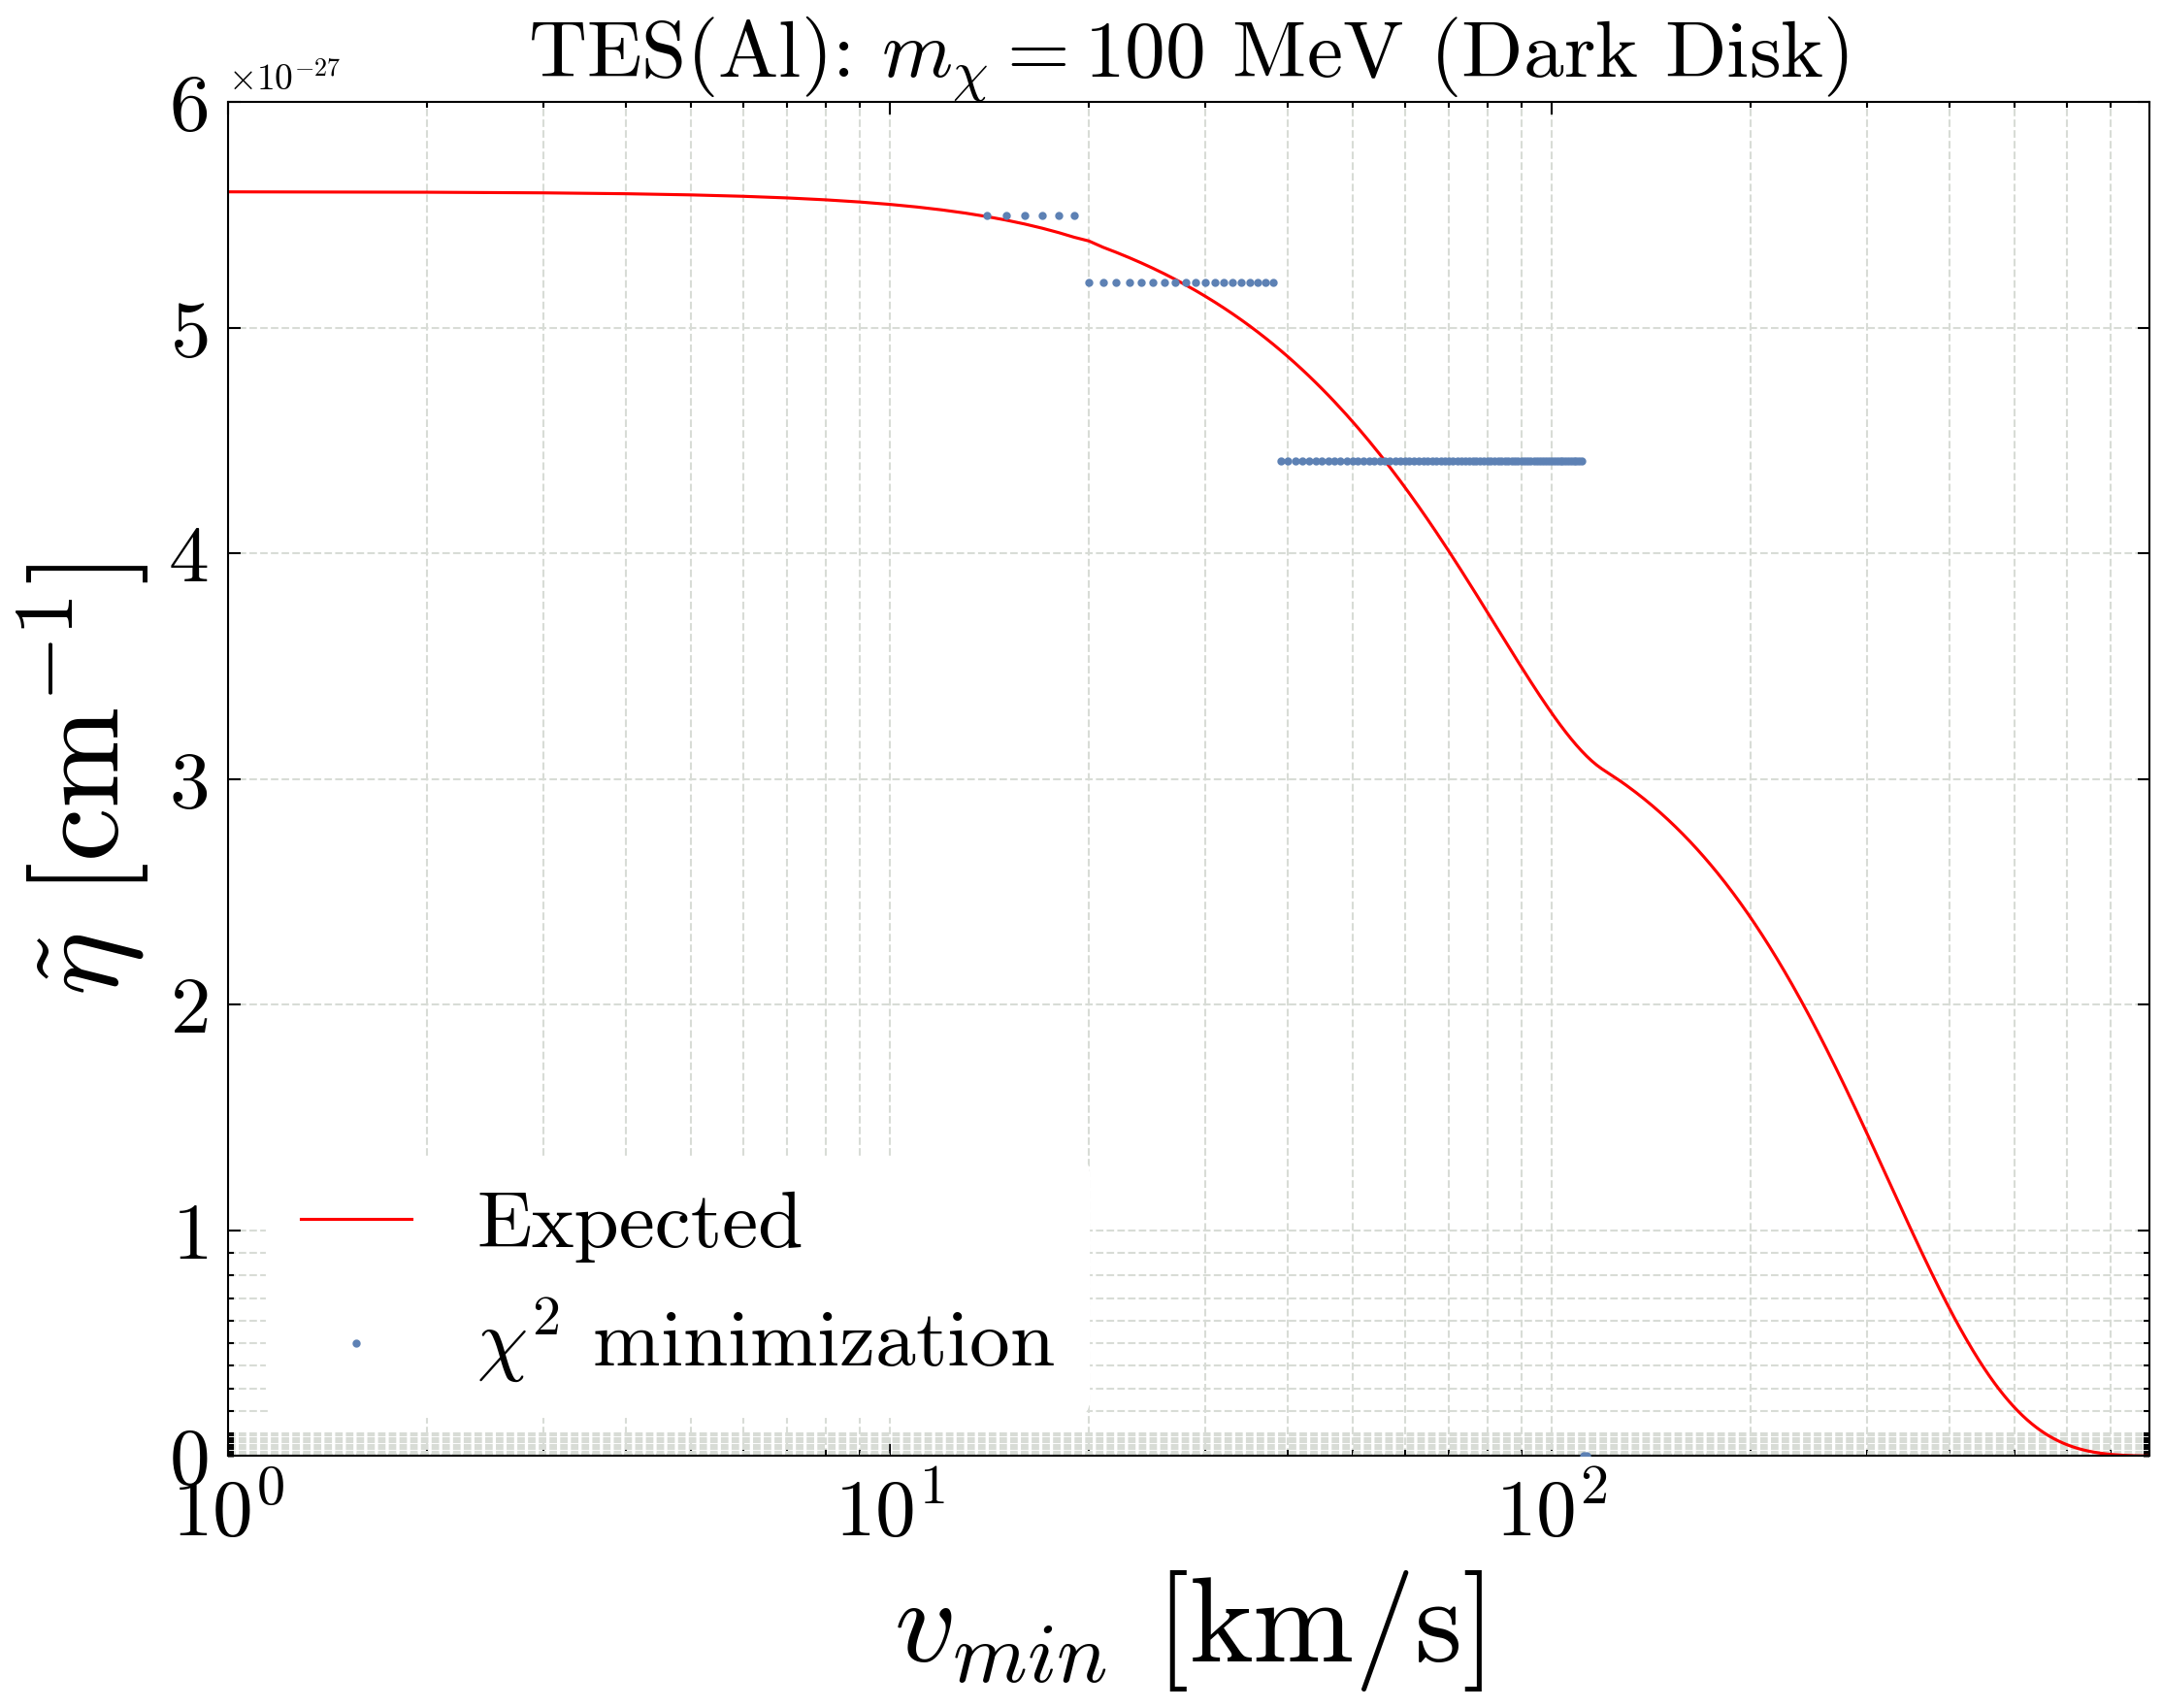

In [14]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'Al', mass = '2', q= '0', cons1 = 2e-13, cons2 = 1e19)#5.8e-3, cons1 = 3.7e-13, cons2 = 1e19
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 6e-27)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 100$ MeV (Dark Disk)', fontsize=20)
    plt.savefig('results/TES_100MeV_q=0_Disk.pdf')

In [262]:
analysis_none.CRmat@analysis_none.fig1Solid[13:113]/analysis_none.cm

array([1515.77842222, 3081.25178787, 4514.78113621, 5860.63130032,
       7137.87010689])

In [15]:
TESDisk100MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESDisk100MeV.csv', TESDisk100MeV)

In [263]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([1516.89636633, 3040.78857328, 4524.85176468, 5910.26934415,
       7116.46745472])

In [264]:
analysis_none.Ratebin2

array([1515.77842222, 3081.25178787, 4514.78113621, 5860.63130032,
       7137.87010689])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  209  |   0   | +2.3023e+23 | 1.00e+00 | 2.73e+14 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  418  |   1   | +2.3023e+23 | 7.00e+00 | 2.80e+14 | 2.97e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  627  |   2   | +2.3023e+23 | 4.90e+01 | 2.64e+14 | 2.57e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  836  |   4   | +2.3023e+23 | 2.04e+02 | 2.74e+14 | 7.17e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 1045  |  95   | +2.3023e+23 | 2.04e+02 | 2.76e+14 | 3.94e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   6   | 1254  |  96   | +2.3023e+23 | 2.04e+02 | 2.78e+14 | 2.21e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 1463  |  97   | +2.3023e+23 | 2.16e+02 | 2.79e+14 | 1.23e-01 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


| 1360  |285076 | 39935 | +9.4172e+17 | 1.78e+00 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1361  |285285 | 39936 | +9.4172e+17 | 1.78e+00 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1362  |285703 | 39937 | +9.4172e+17 | 8.90e-01 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1363  |286121 | 39938 | +9.4172e+17 | 4.45e-01 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1364  |286539 | 39939 | +9.4172e+17 | 2.23e-01 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1365  |286957 | 39940 | +9.4172e+17 | 1.11e-01 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1366  |287375 | 39941 | +9.4172e+17 | 5.56e-02 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1367  |287793 | 39942 | +9.4172e+17 | 2.78e-02 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1368  |288211 | 39943 | +9.4172e+17 | 1.39e-02 | 7.24e+07 | 0.00e+00 | 3.34e+18 |  1.00e-01   |   2   |
| 1369  |288629 | 39944 | +9.4172e+17 | 6.96e-

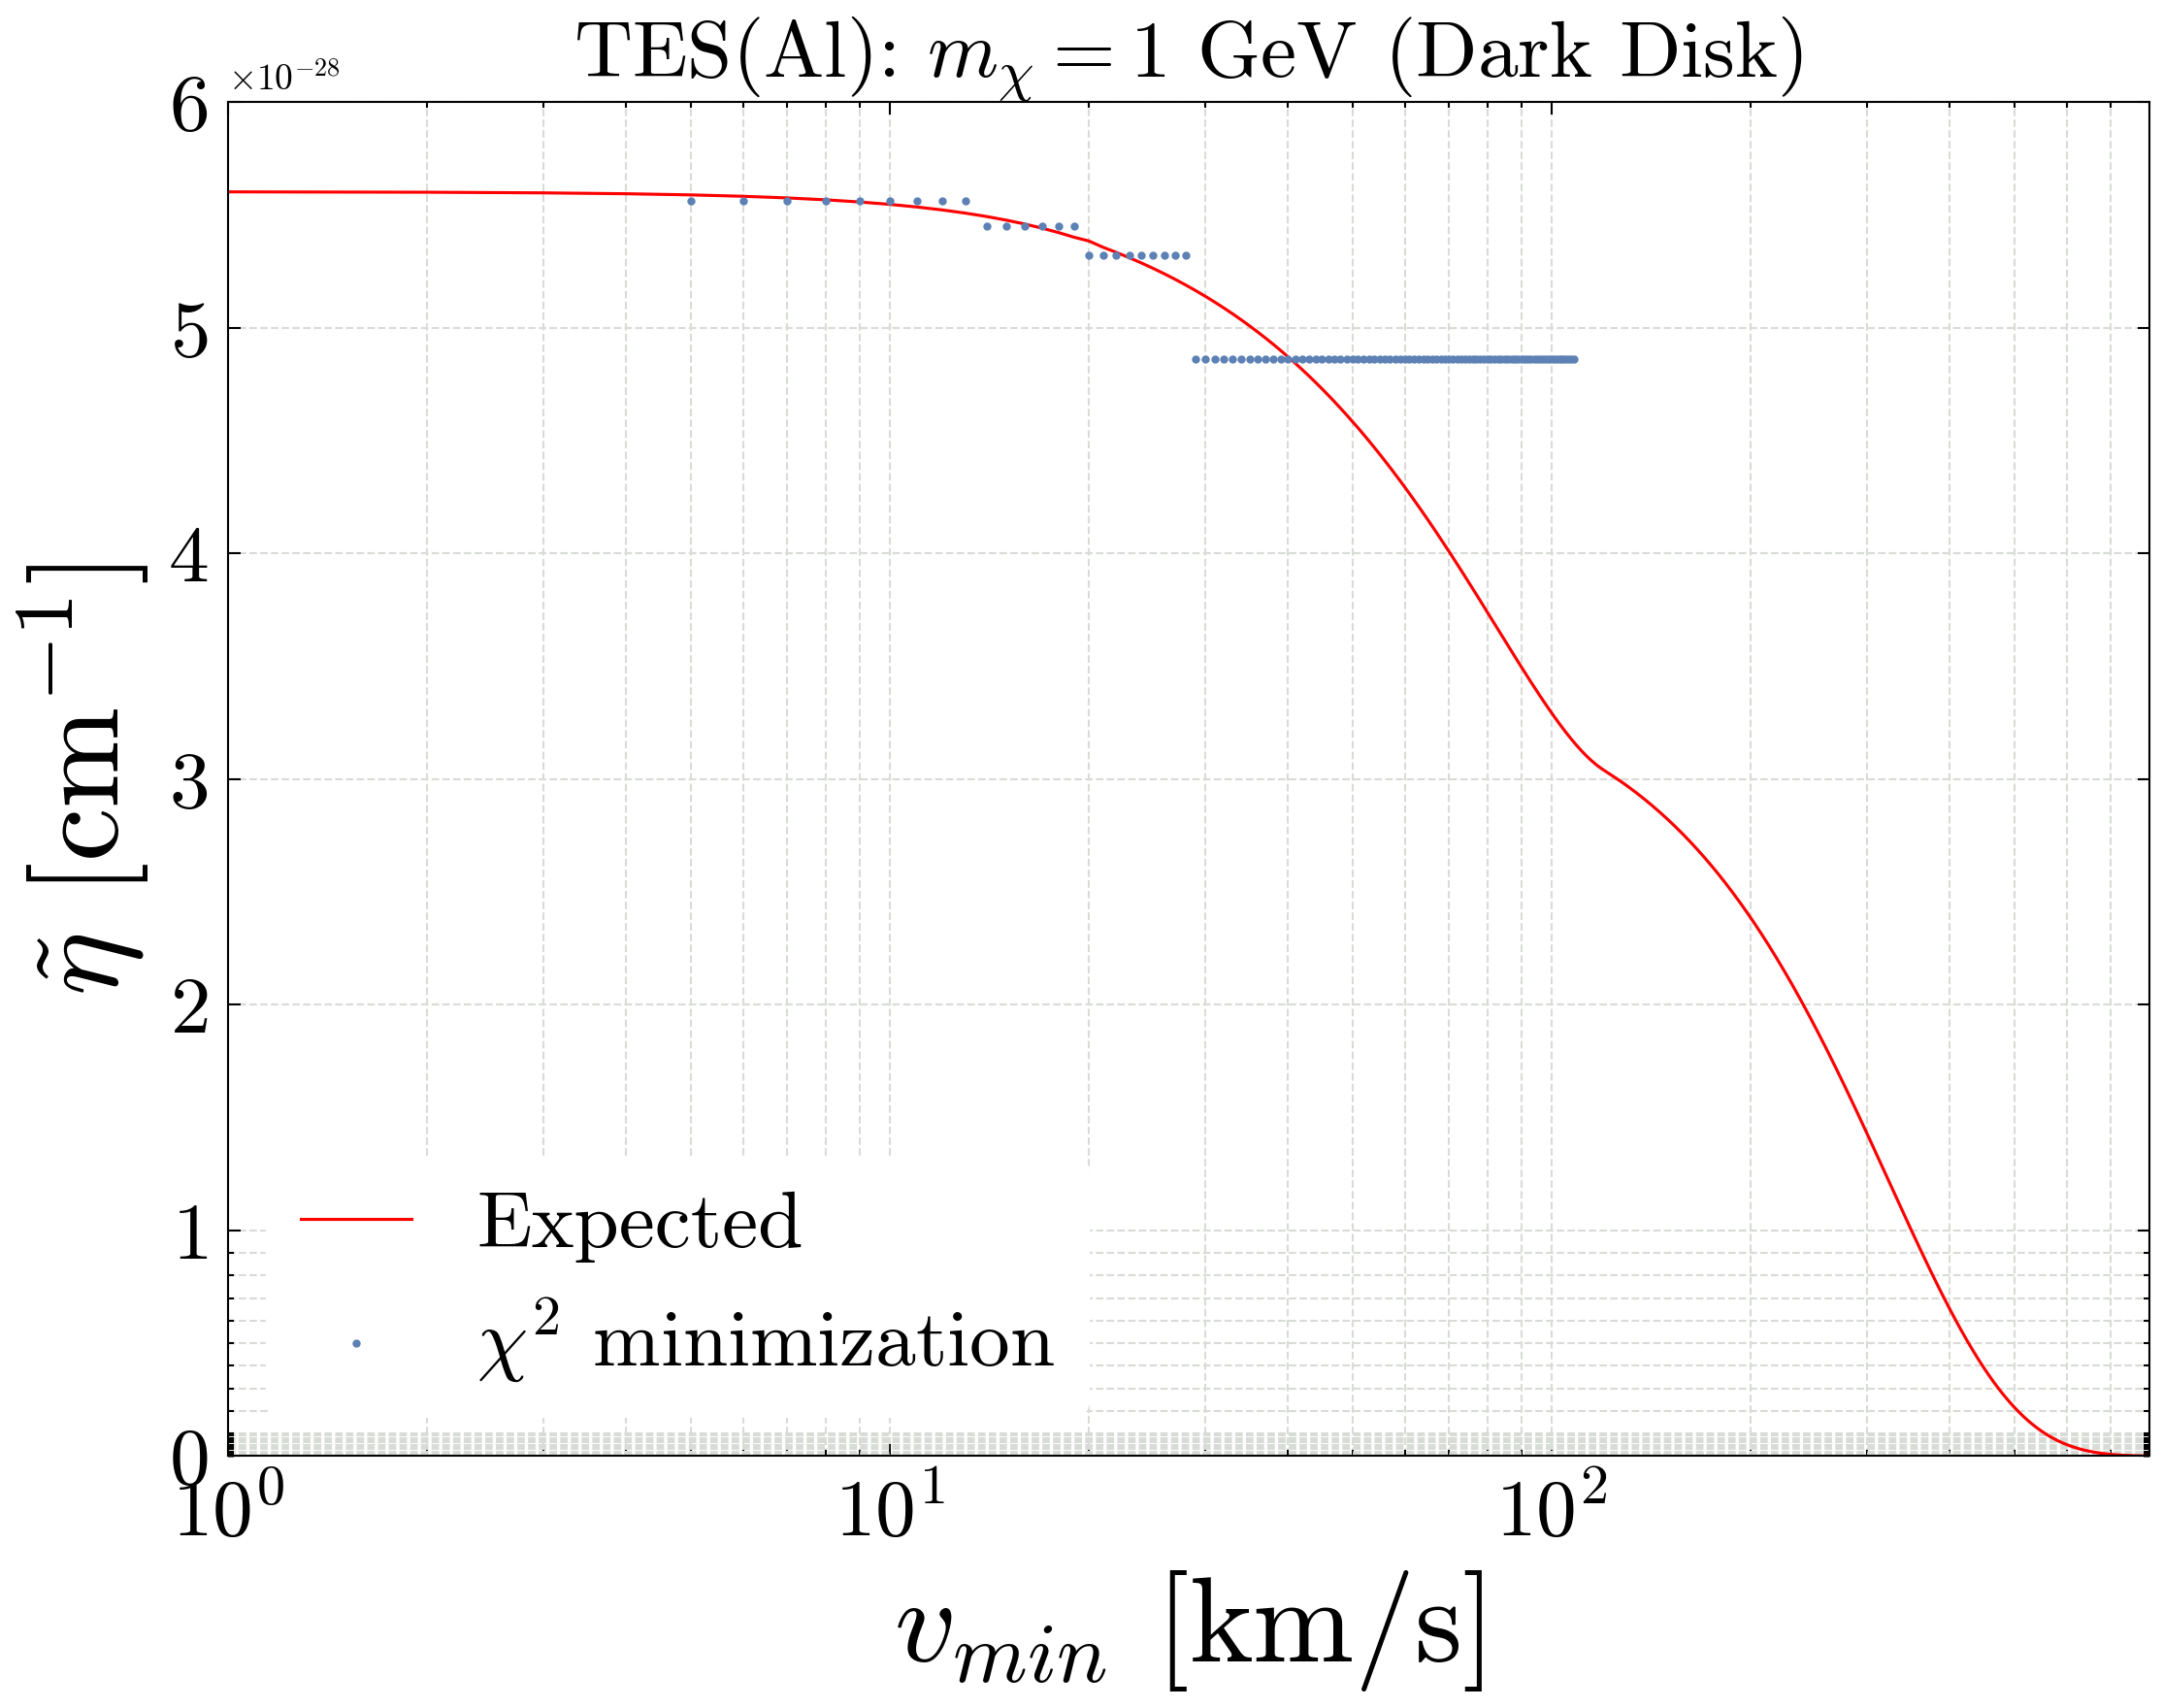

In [16]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'Al', mass = '3', q= '0', cons1 = 2e-13, cons2 = 1e20)#5.8e-3
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 6e-28)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 1$ GeV (Dark Disk)', fontsize=20)
    plt.savefig('results/TES_1GeV_q=0_Disk.pdf')

In [28]:
analysis_none.CRmat@analysis_none.fig1Solid[4:108]/analysis_none.cm

array([157.73985056, 314.65193556, 469.33417818, 611.99960066,
       748.60614499])

In [10]:
TESDisk1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESDisk1000MeV.csv', TESDisk1000MeV)

In [202]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 420.84133967,  830.99478544, 1221.67040545, 1564.82800527,
       1876.40664487])

### Bound

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  249  |   0   | +1.2117e+45 | 1.00e+00 | 5.32e+43 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  498  |   1   | +1.1169e+45 | 7.00e+00 | 4.70e+43 | 1.58e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  747  |   2   | +4.0825e+44 | 4.90e+01 | 9.65e+42 | 1.05e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  996  |  75   | +1.1745e+44 | 5.50e+01 | 1.48e+42 | 1.13e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   5   | 1245  |  172  | +4.4468e+43 | 5.50e+01 | 6.31e+41 | 1.02e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   6   | 1494  |  296  | +1.7617e+43 | 5.50e+01 | 2.56e+41 | 9.14e-02 | 1.00e+00 |  1.00e-01   |   1   |
|   7   | 1743  |  420  | +9.0403e+42 | 5.50e+01 | 1.22e+41 | 6.19e-02 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  223  | 61752 | 7249  | +5.8001e+35 | 5.22e+01 | 1.58e+28 | 5.47e-10 | 6.17e+35 |  2.00e-02   |   2   |
|  224  | 62001 | 7267  | +5.8001e+35 | 1.90e+02 | 6.48e+27 | 1.69e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  225  | 62250 | 7276  | +5.8001e+35 | 1.25e+03 | 6.23e+27 | 1.23e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  226  | 62499 | 7282  | +5.8001e+35 | 2.17e+03 | 2.41e+28 | 8.01e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  227  | 62748 | 7295  | +5.8001e+35 | 2.25e+03 | 4.63e+27 | 1.78e-09 | 1.90e+36 |  2.00e-02   |   2   |
|  228  | 62997 | 7298  | +5.8001e+35 | 2.25e+03 | 2.23e+28 | 1.20e-09 | 1.90e+36 |  2.00e-02   |   2   |
|  229  | 63246 | 7301  | +5.7487e+35 | 1.58e+04 | 1.24e+33 | 7.33e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  230  | 63495 | 7305  | +5.7487e+35 | 1.58e+03 | 1.24e+33 | 7.33e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  231  | 63744 | 7309  | +2.6205e+32 | 1.64e+03 | 1.33e+33 | 4.59e-10 | 1.90e+36 |  2.00e-02   |   2   |
|  232  | 63993 | 7338  | +9.4054e+31 | 6.34e+

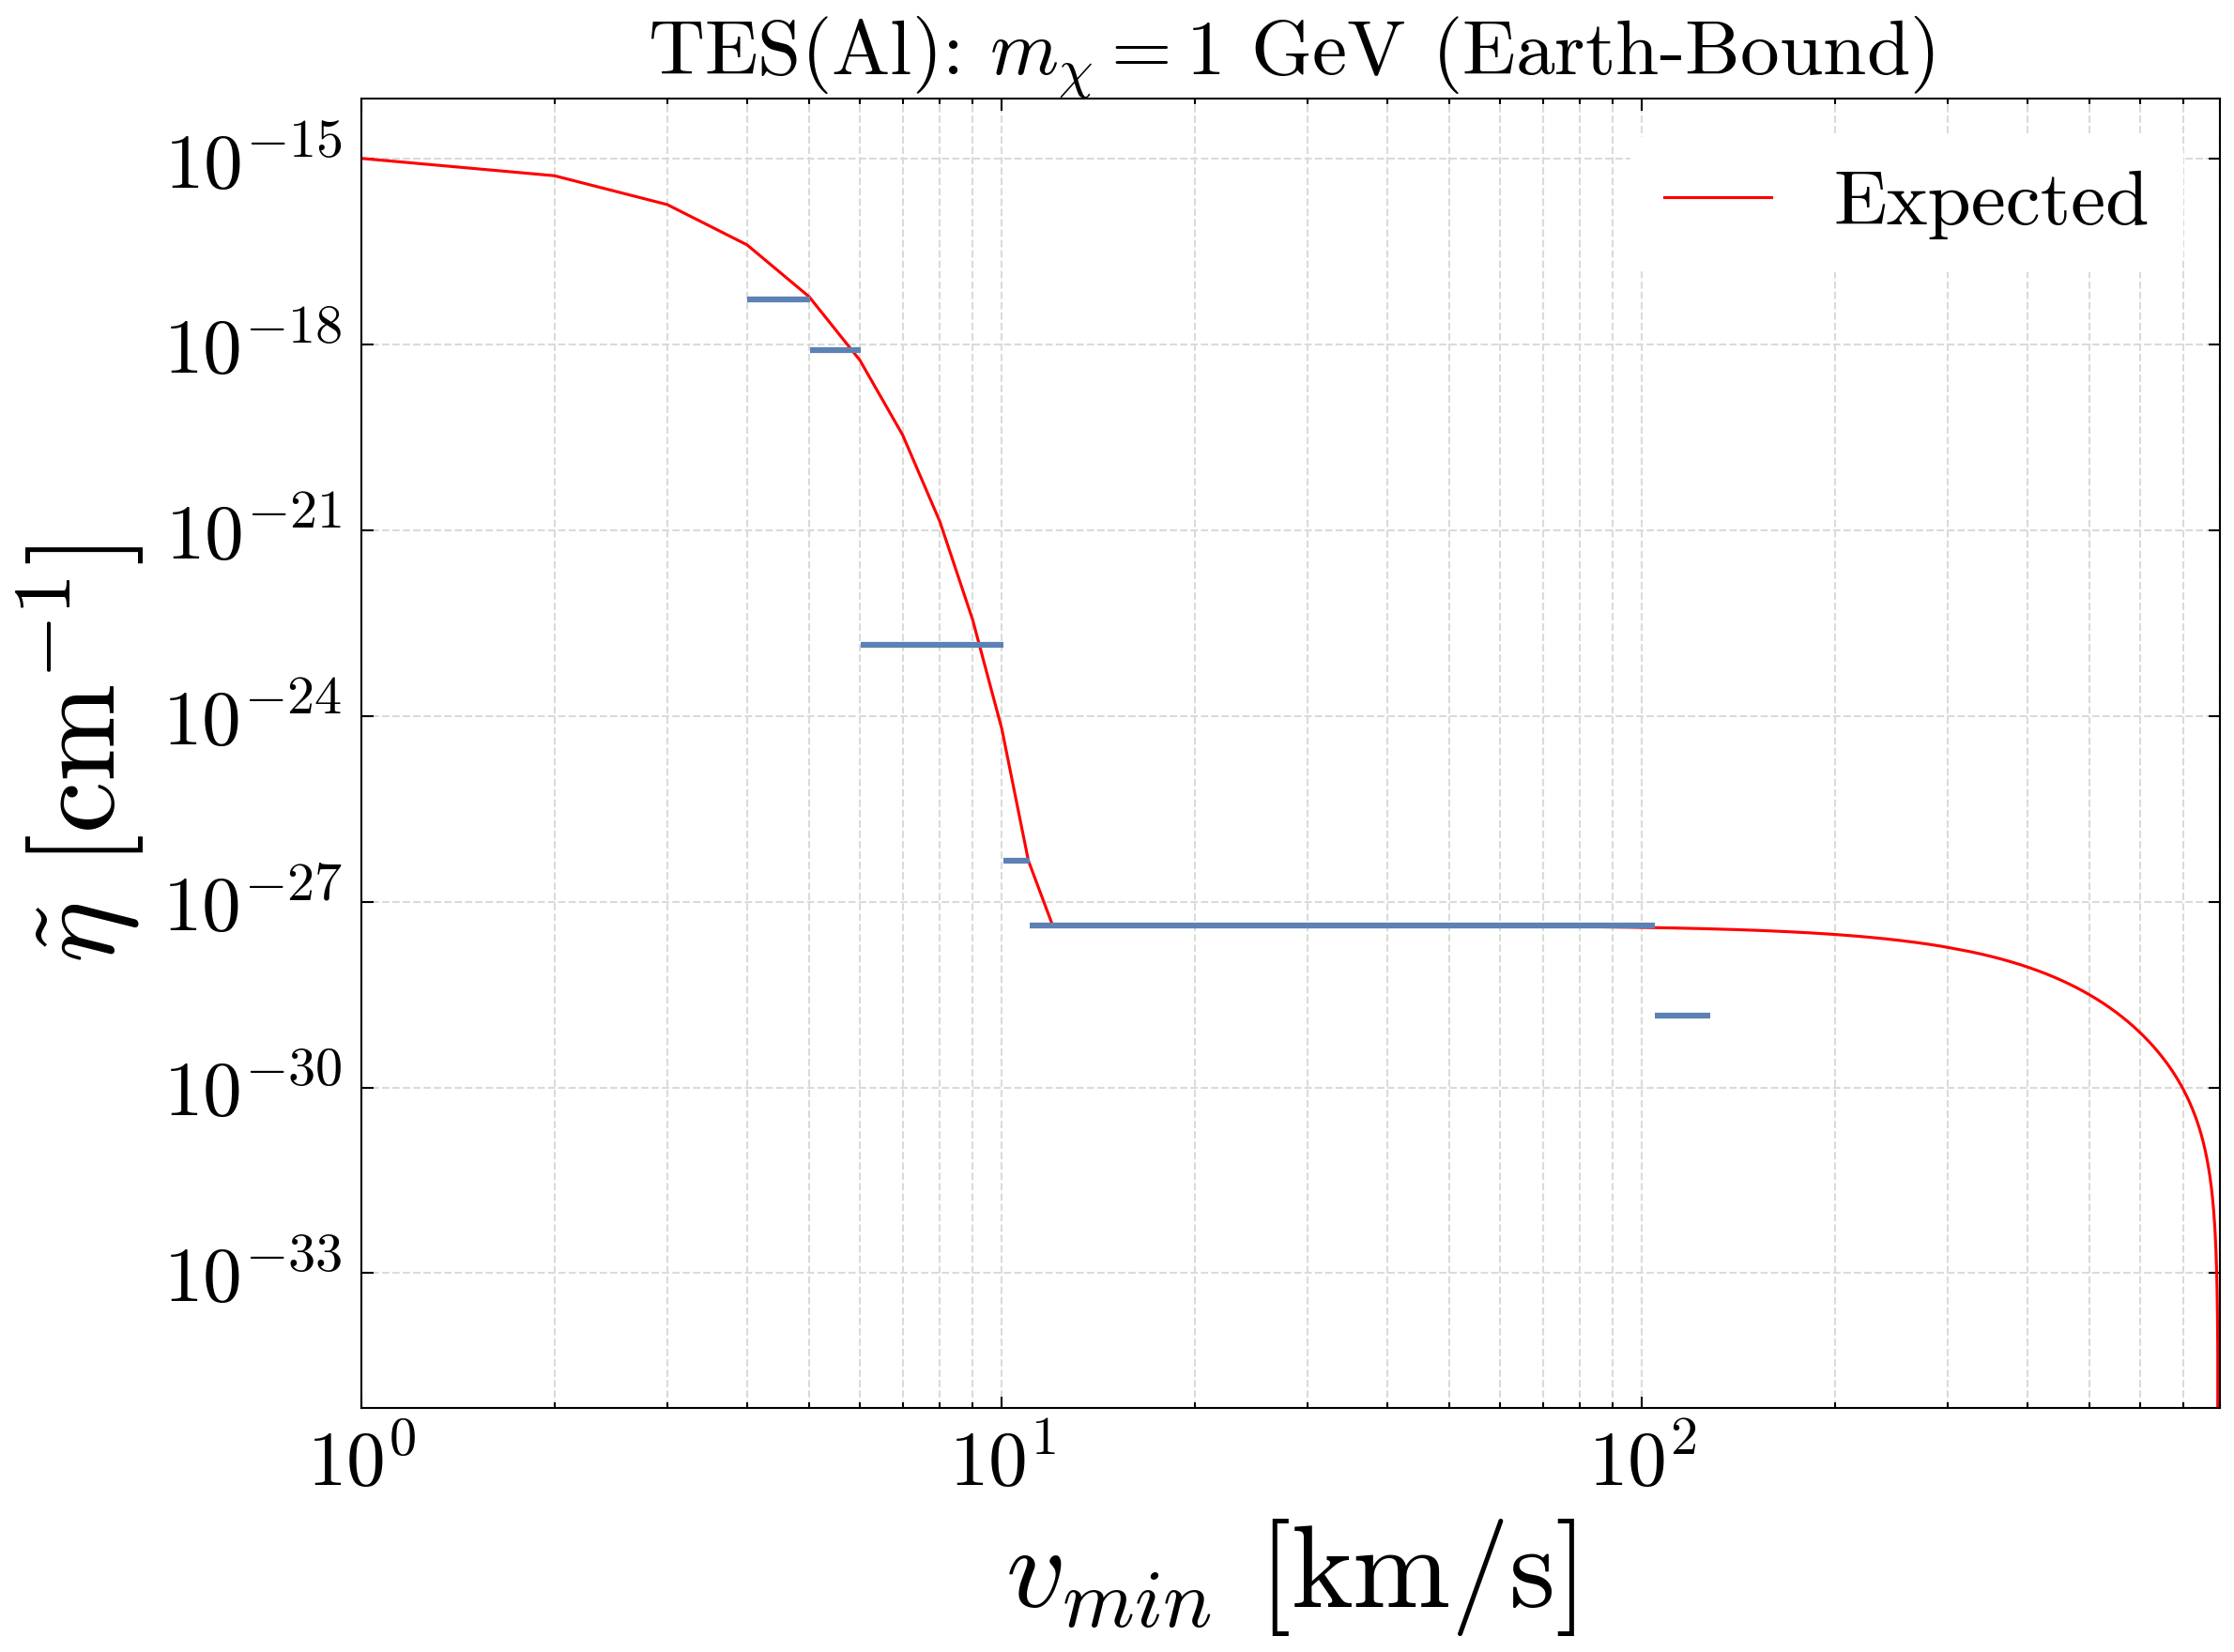

In [96]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
#from neutrino_analysis_refined import NeutrinoAnalysis
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Bound', material = 'Al', mass = '3', q= '0', cons1 = 1, cons2 = 9e23)#, cons1 = 1e23, cons2 = 4e50, 1e-4, 1e10
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(1e-29, 1e-13)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    plt.yscale('log')

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'TES(Al): $m_\chi = 1$ GeV (Earth-Bound)', fontsize=20)
    plt.savefig('results/TES_1GeV_q=0_Bound.pdf')

In [85]:
analysis_none.CRmat@analysis_none.fig1Solid[4:128]/analysis_none.cm

array([6.01091363e+12, 2.93787777e+11, 1.05000798e+08, 4.70905864e+04,
       4.54689840e+04])

In [125]:
np.savetxt('results/events/events_TESBound1000MeV.csv', 3.32323e-6 * np.array([2.18187938e+13, 2.01638243e+12, 4.75747927e+09, 2.82515571e+06, 4.68716372e+04]))

In [92]:
def boundHalo(vmin):
    return np.interp(vmin, np.linspace(1, 800, 800), analysis_none.fig1Solid / analysis_none.cm)

In [97]:
TESBound1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/TESBound1000MeV.csv', TESBound1000MeV)

In [41]:
analysis_none.CRmat[0][0] / analysis_none.cm

np.float64(4.5026475731449475e-29)

In [13]:
analysis_none.CRmat@boundHalo(np.linspace(5, 108, 200))

array([3.06723047e+04, 2.85747510e+02, 8.92641528e-01, 6.62580549e-04,
       6.42739040e-05])

In [44]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([6.16951335e+11, 7.73758237e+10, 8.30611159e+09, 6.46195102e+08,
       4.66775036e+07])

In [45]:
analysis_none.Ratebin2

array([6.16951335e+11, 7.73758237e+10, 8.30611159e+09, 6.46195102e+08,
       4.66775036e+07])

# M-KID

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  399  |   0   | +1.3448e+42 | 1.00e+00 | 4.28e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  798  |   1   | +1.3448e+42 | 7.00e+00 | 4.32e+35 | 3.17e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   | 1197  |   2   | +1.3448e+42 | 4.90e+01 | 4.83e+35 | 2.15e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   | 1596  |   3   | +1.3446e+42 | 3.43e+02 | 5.93e+35 | 1.83e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 1995  |   4   | +1.3444e+42 | 3.43e+02 | 5.70e+35 | 2.21e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 2394  |   5   | +1.3444e+42 | 3.43e+02 | 5.30e+35 | 1.95e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 2793  |   6   | +1.3443e+42 | 3.43e+02 | 4.89e+35 | 1.68e-01 | 1.00e+00 |  1.00e-01   

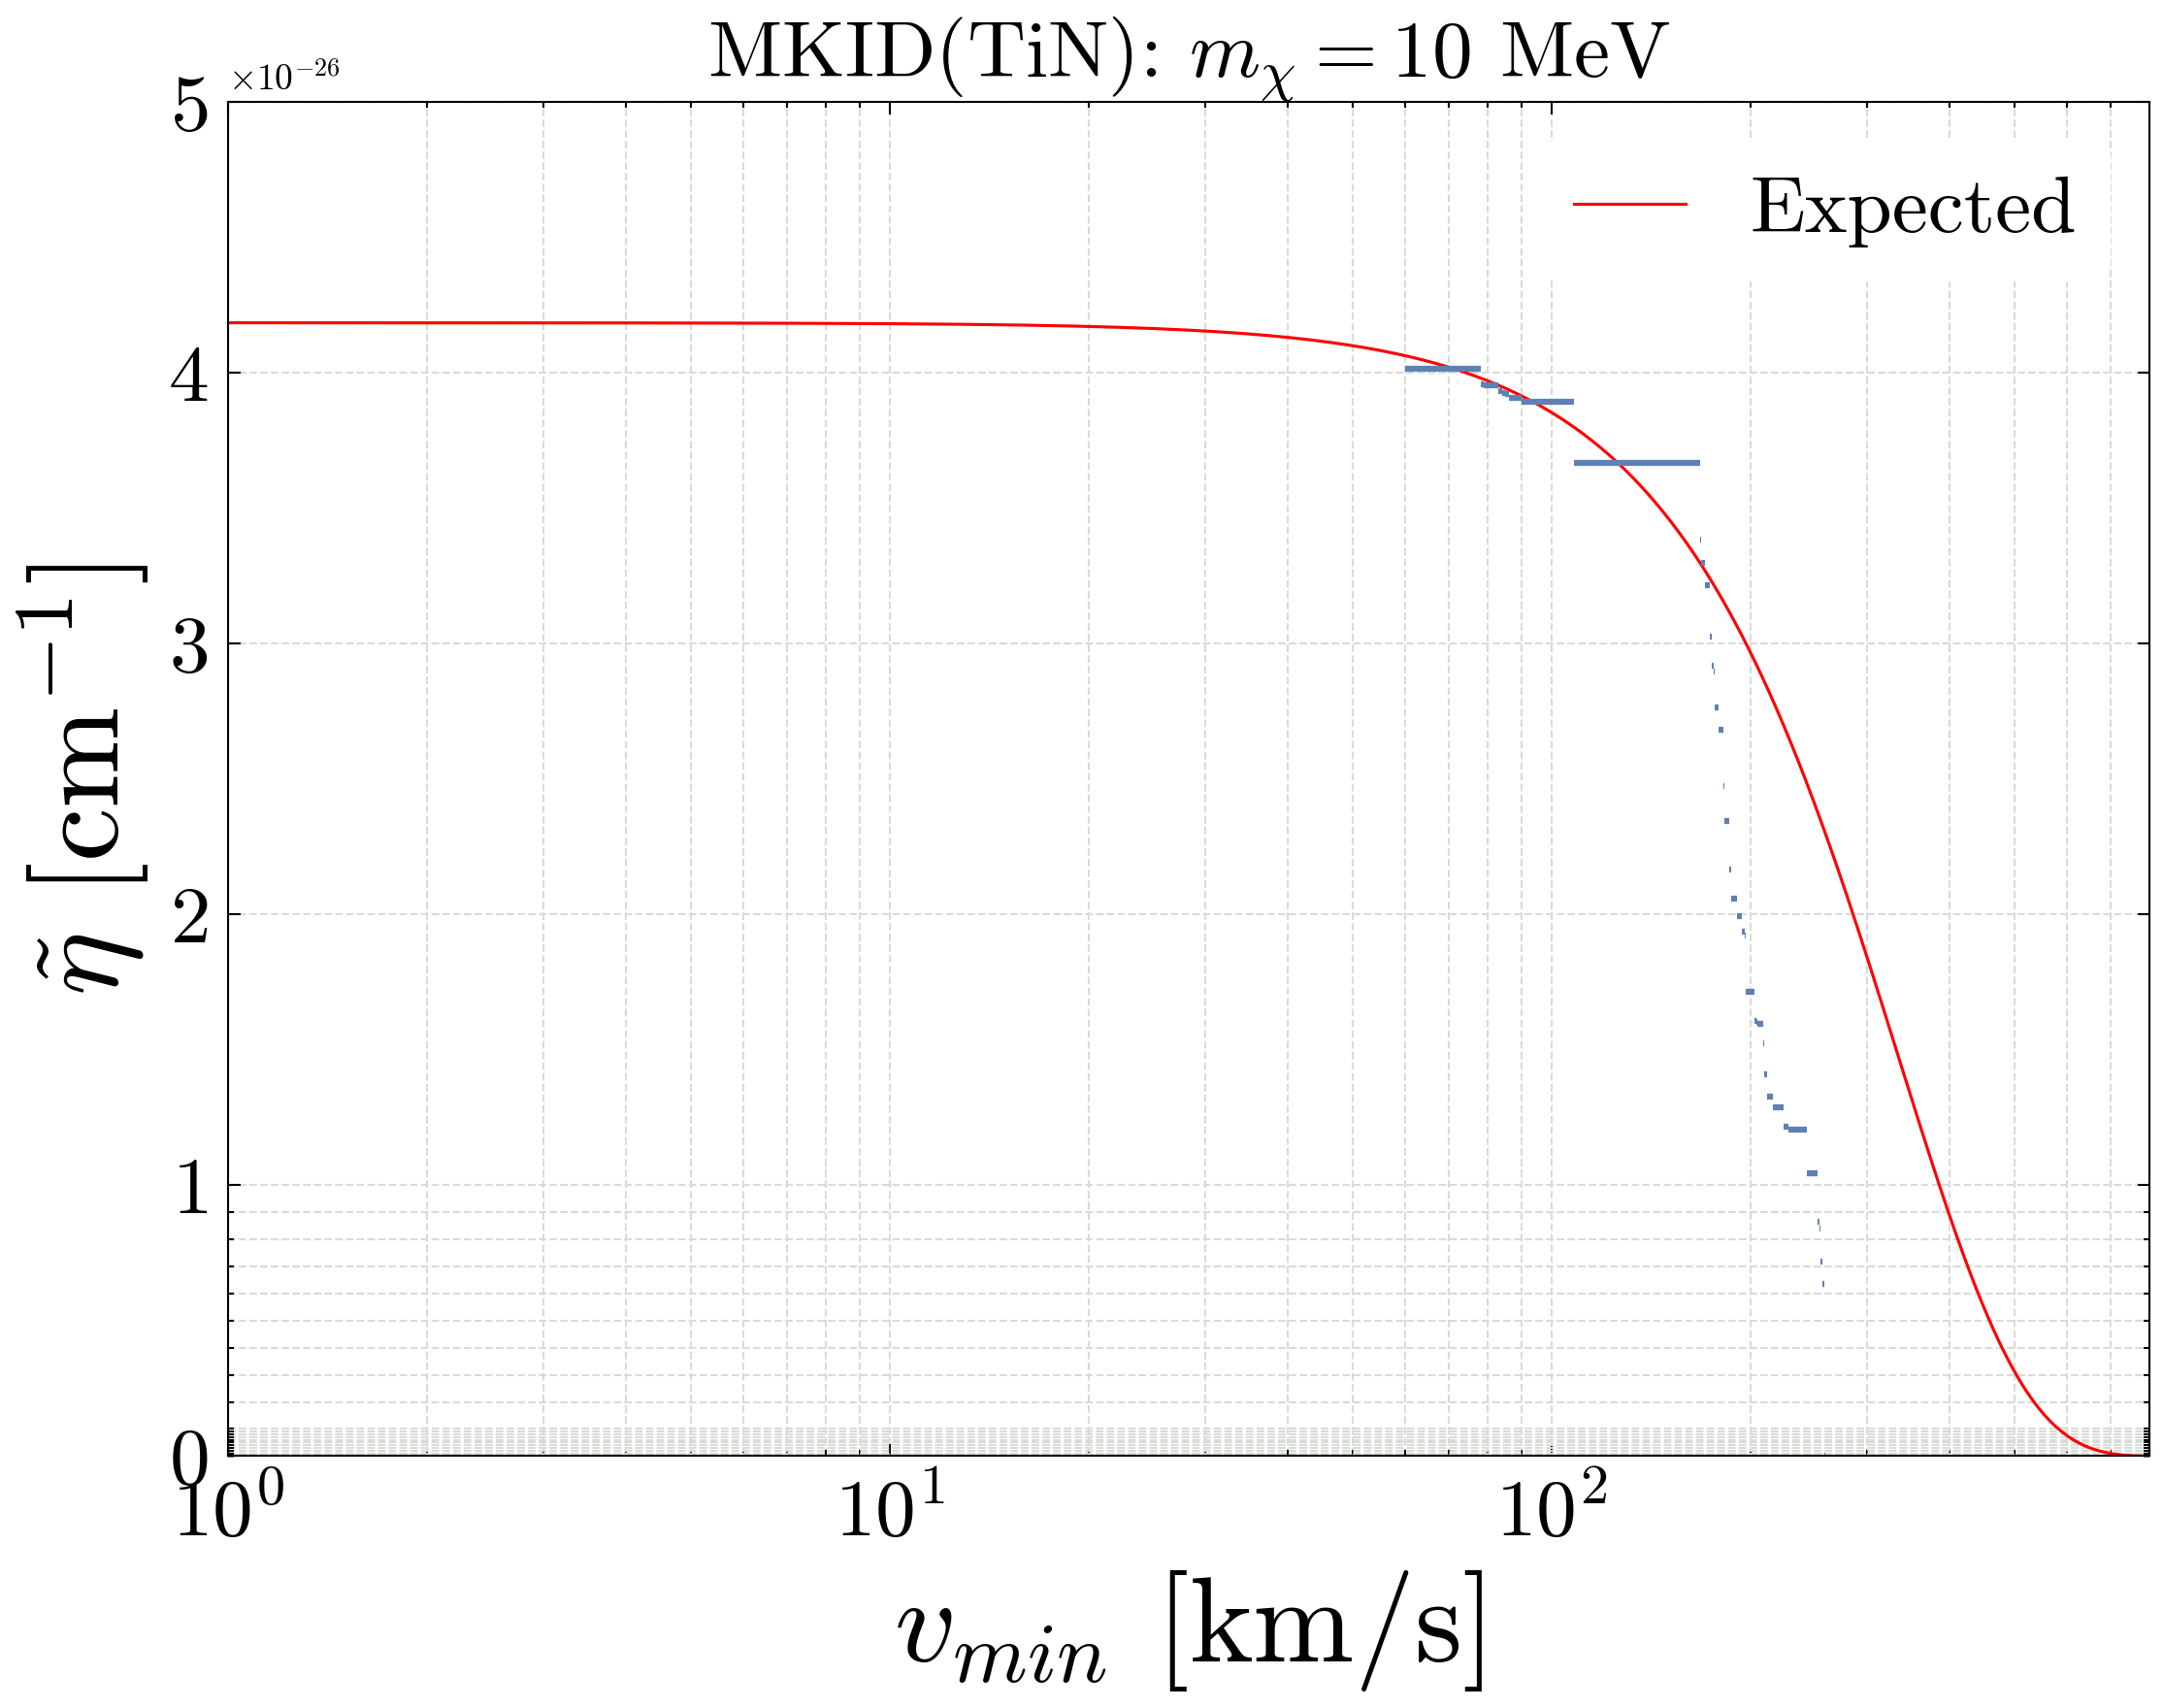

In [54]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'TiN', mass = '1', q= '0', cons1 = 1, cons2 = 9e34)#, cons1 = 1e34, cons2 = 4e61, const1 = 8e-5, const2 = 1e9
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-19, 5e-19)
    plt.ylim(0, 5e-26)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 10$ MeV', fontsize=20)
    plt.savefig('results/MKID_10MeV_q=0_SHM.pdf')

In [51]:
analysis_none.CRmat@analysis_none.fig1Solid[60:259]/analysis_none.cm

array([ 628165.78580323, 2140887.68847306, 3219235.41201157,
       4077674.49683591, 4876743.68890528])

In [137]:
np.savetxt('results/events/events_MKIDSHM10MeV.csv', 3.32323e-6 * np.array([ 646276.93081915, 2199104.02693467, 3298303.67564205, 4164721.5004773 , 4962482.15504315]))

In [55]:
MKIDSHM10MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDSHM10MeV.csv', MKIDSHM10MeV)

In [77]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 646276.93081915, 2199104.02693467, 3298303.67564205,
       4164721.5004773 , 4962482.15504315])

In [89]:
analysis_none.Ratebin2

array([ 750.3936629 , 2471.06791425, 3792.71418013, 4874.08084443,
       5870.58628703])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  461  |   0   | +1.3307e+41 | 1.00e+00 | 3.55e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  922  |   1   | +1.3307e+41 | 7.00e+00 | 3.58e+35 | 3.47e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   | 1383  |   2   | +1.3305e+41 | 4.90e+01 | 4.01e+35 | 2.02e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   | 1844  |   3   | +1.3289e+41 | 3.43e+02 | 4.96e+35 | 2.06e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 2305  |   4   | +1.3277e+41 | 3.43e+02 | 4.83e+35 | 2.20e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 2766  |   5   | +1.3269e+41 | 3.43e+02 | 4.49e+35 | 1.79e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 3227  |   6   | +1.3259e+41 | 3.43e+02 | 4.19e+35 | 1.49e-01 | 1.00e+00 |  1.00e-01   

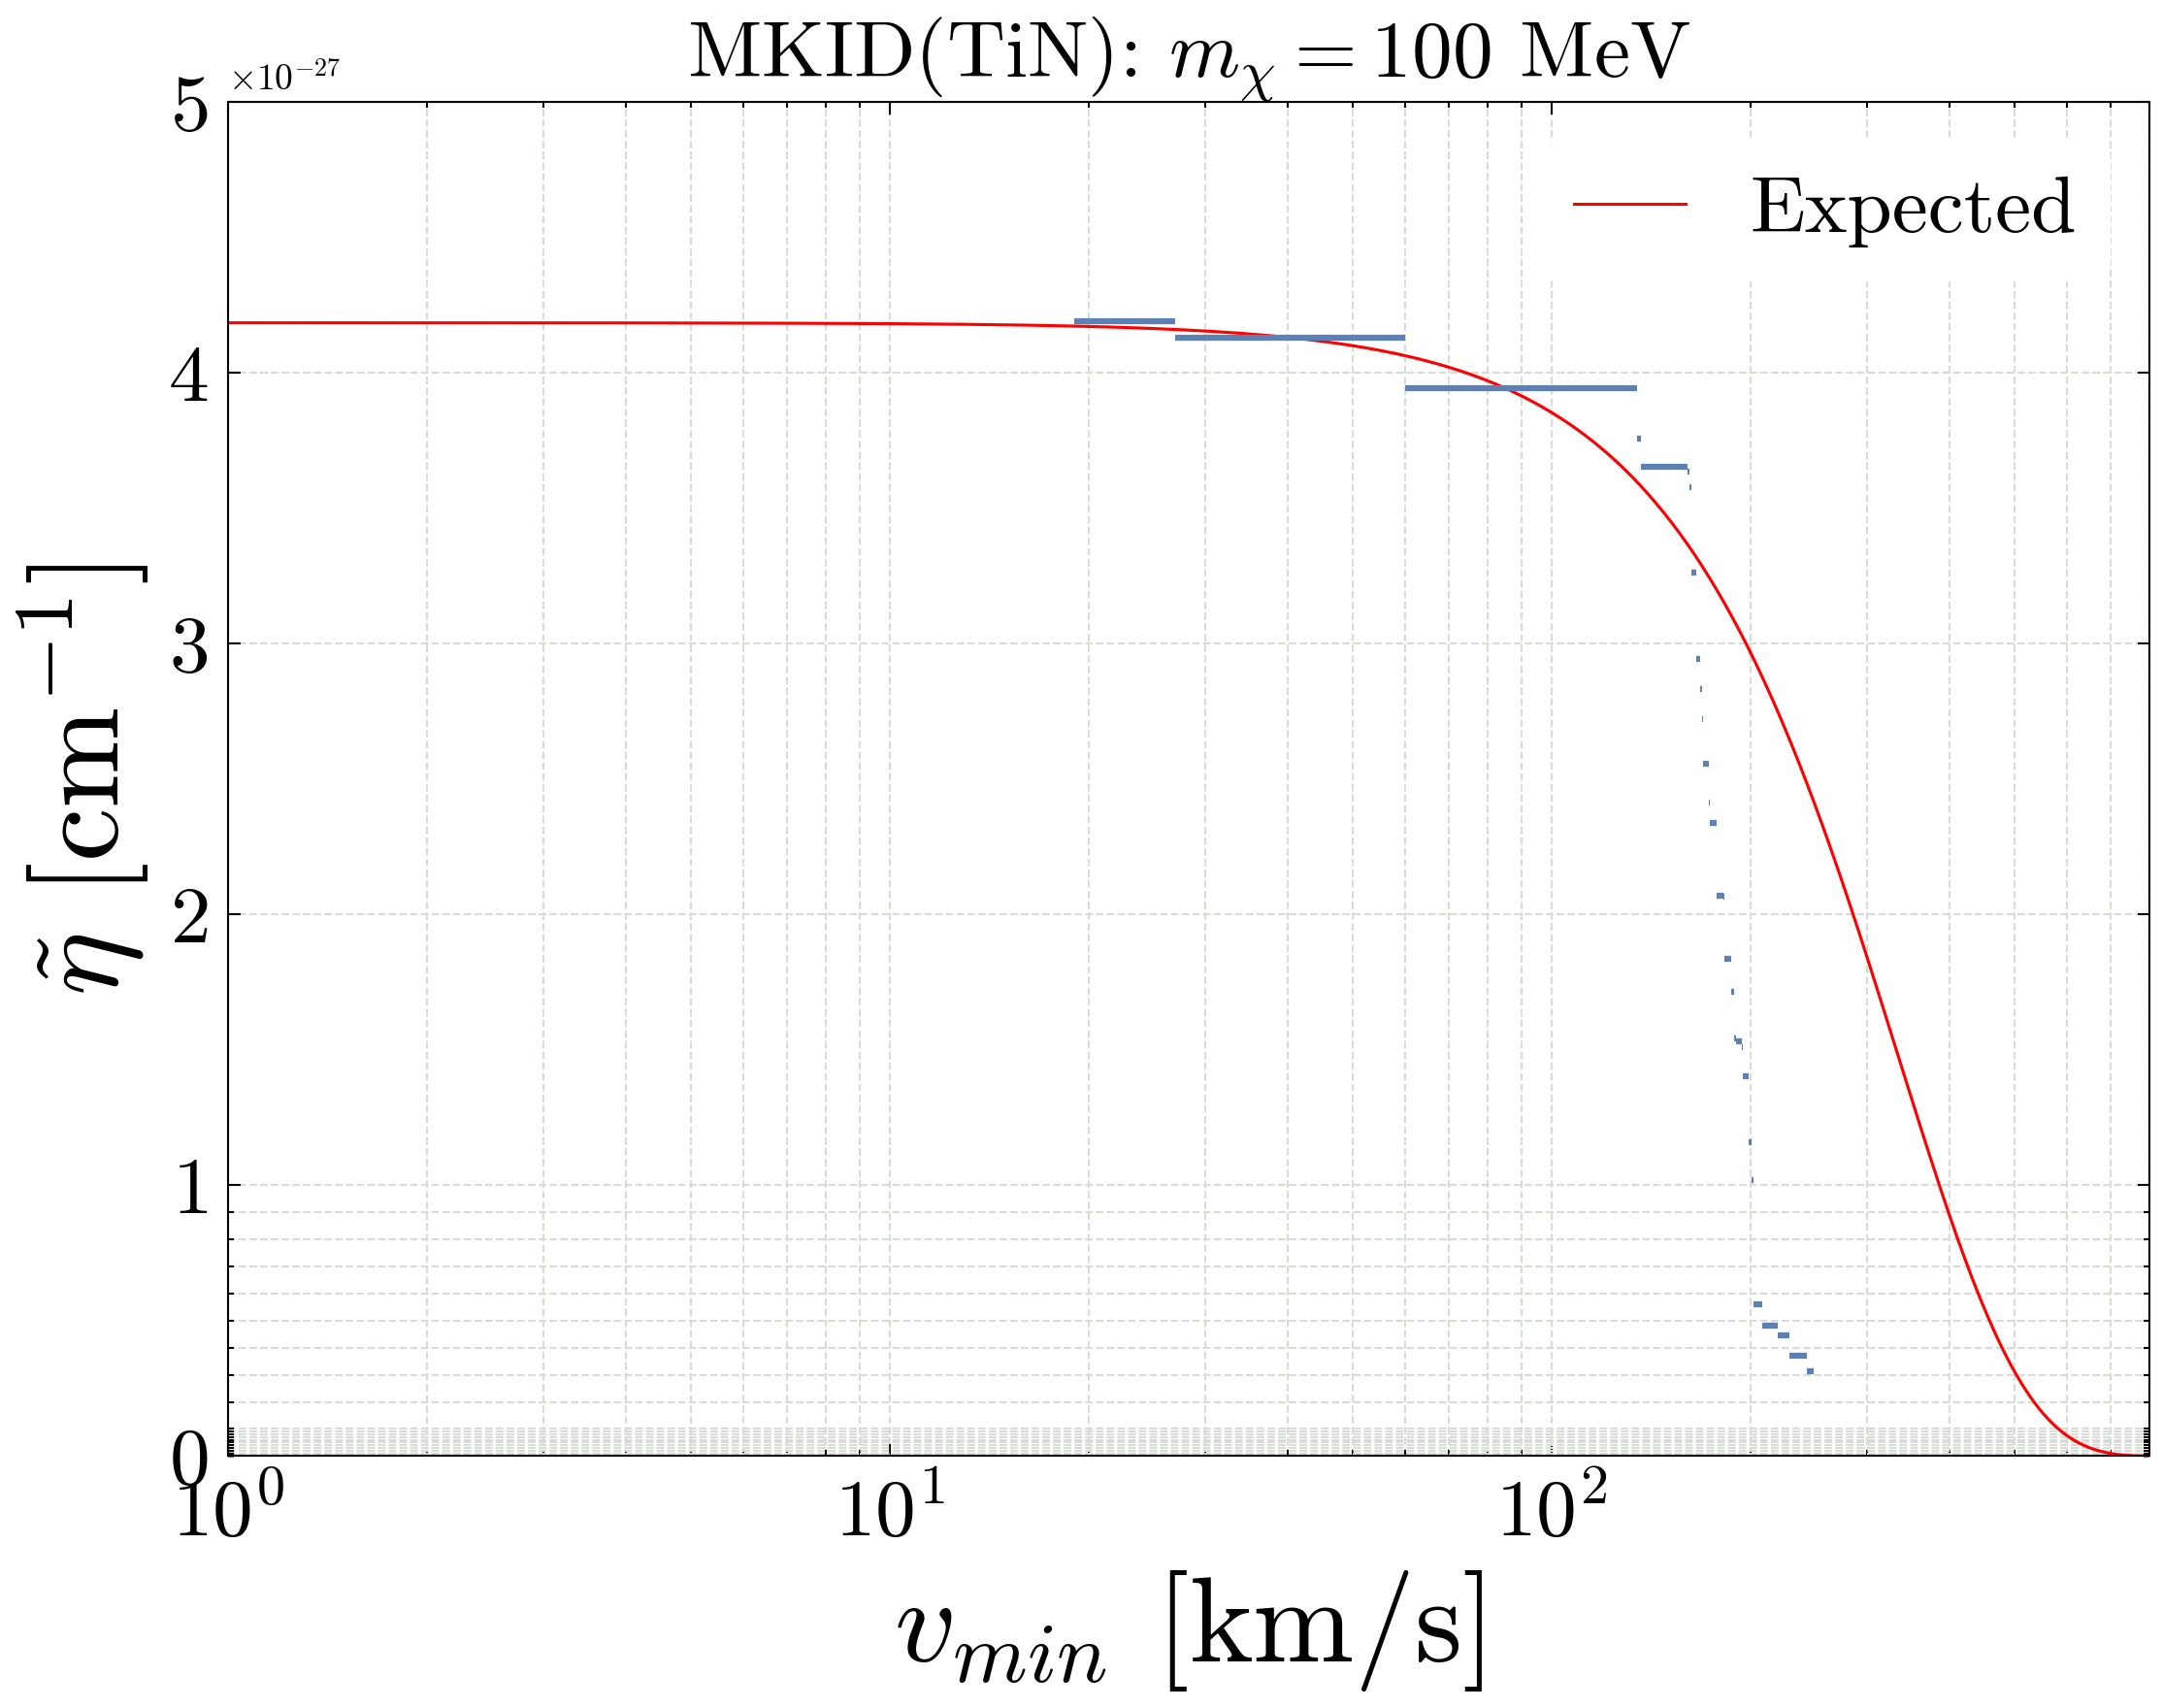

In [63]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'TiN', mass = '2', q= '0', cons1 = 1, cons2 = 9e34)#, cons1 = 3e33, cons2 = 4e62, 6.9e-4, , cons1 = 6.9e-4, cons2 = 1e9
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-20, 5e-27)
    plt.ylim(0, 5e-27)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 100$ MeV', fontsize=20)
    plt.savefig('results/MKID_100MeV_q=0_SHM.pdf')

In [60]:
analysis_none.CRmat@analysis_none.fig1Solid[19:249]/analysis_none.cm

array([ 60352.84361969, 211753.66936618, 311683.39035209, 405000.21306287,
       490193.9777345 ])

In [141]:
np.savetxt('results/events/events_MKIDSHM100MeV.csv', 3.32323e-6 * np.array([ 62272.85555134, 218320.00142031, 320874.63813435, 416106.64520659, 502368.57621415]))

In [64]:
MKIDSHM100MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDSHM100MeV.csv', MKIDSHM100MeV)

In [15]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 71.95285326, 242.19500008, 360.48553085, 474.42741245,
       580.42213265])

In [16]:
analysis_none.Ratebin2

array([ 71.95285326, 242.19500008, 360.48553085, 474.42741245,
       580.42213265])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  477  |   0   | +1.3216e+40 | 1.00e+00 | 3.47e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  954  |   1   | +1.3213e+40 | 7.00e+00 | 3.51e+35 | 2.82e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   | 1431  |   2   | +1.3199e+40 | 4.90e+01 | 3.92e+35 | 2.14e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   | 1908  |   3   | +1.3044e+40 | 3.43e+02 | 4.83e+35 | 2.09e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   5   | 2385  |   4   | +1.2941e+40 | 3.43e+02 | 4.72e+35 | 2.30e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 2862  |   5   | +1.2873e+40 | 3.43e+02 | 4.40e+35 | 1.91e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 3339  |   6   | +1.2795e+40 | 3.43e+02 | 4.06e+35 | 1.61e-01 | 1.00e+00 |  1.00e-01   

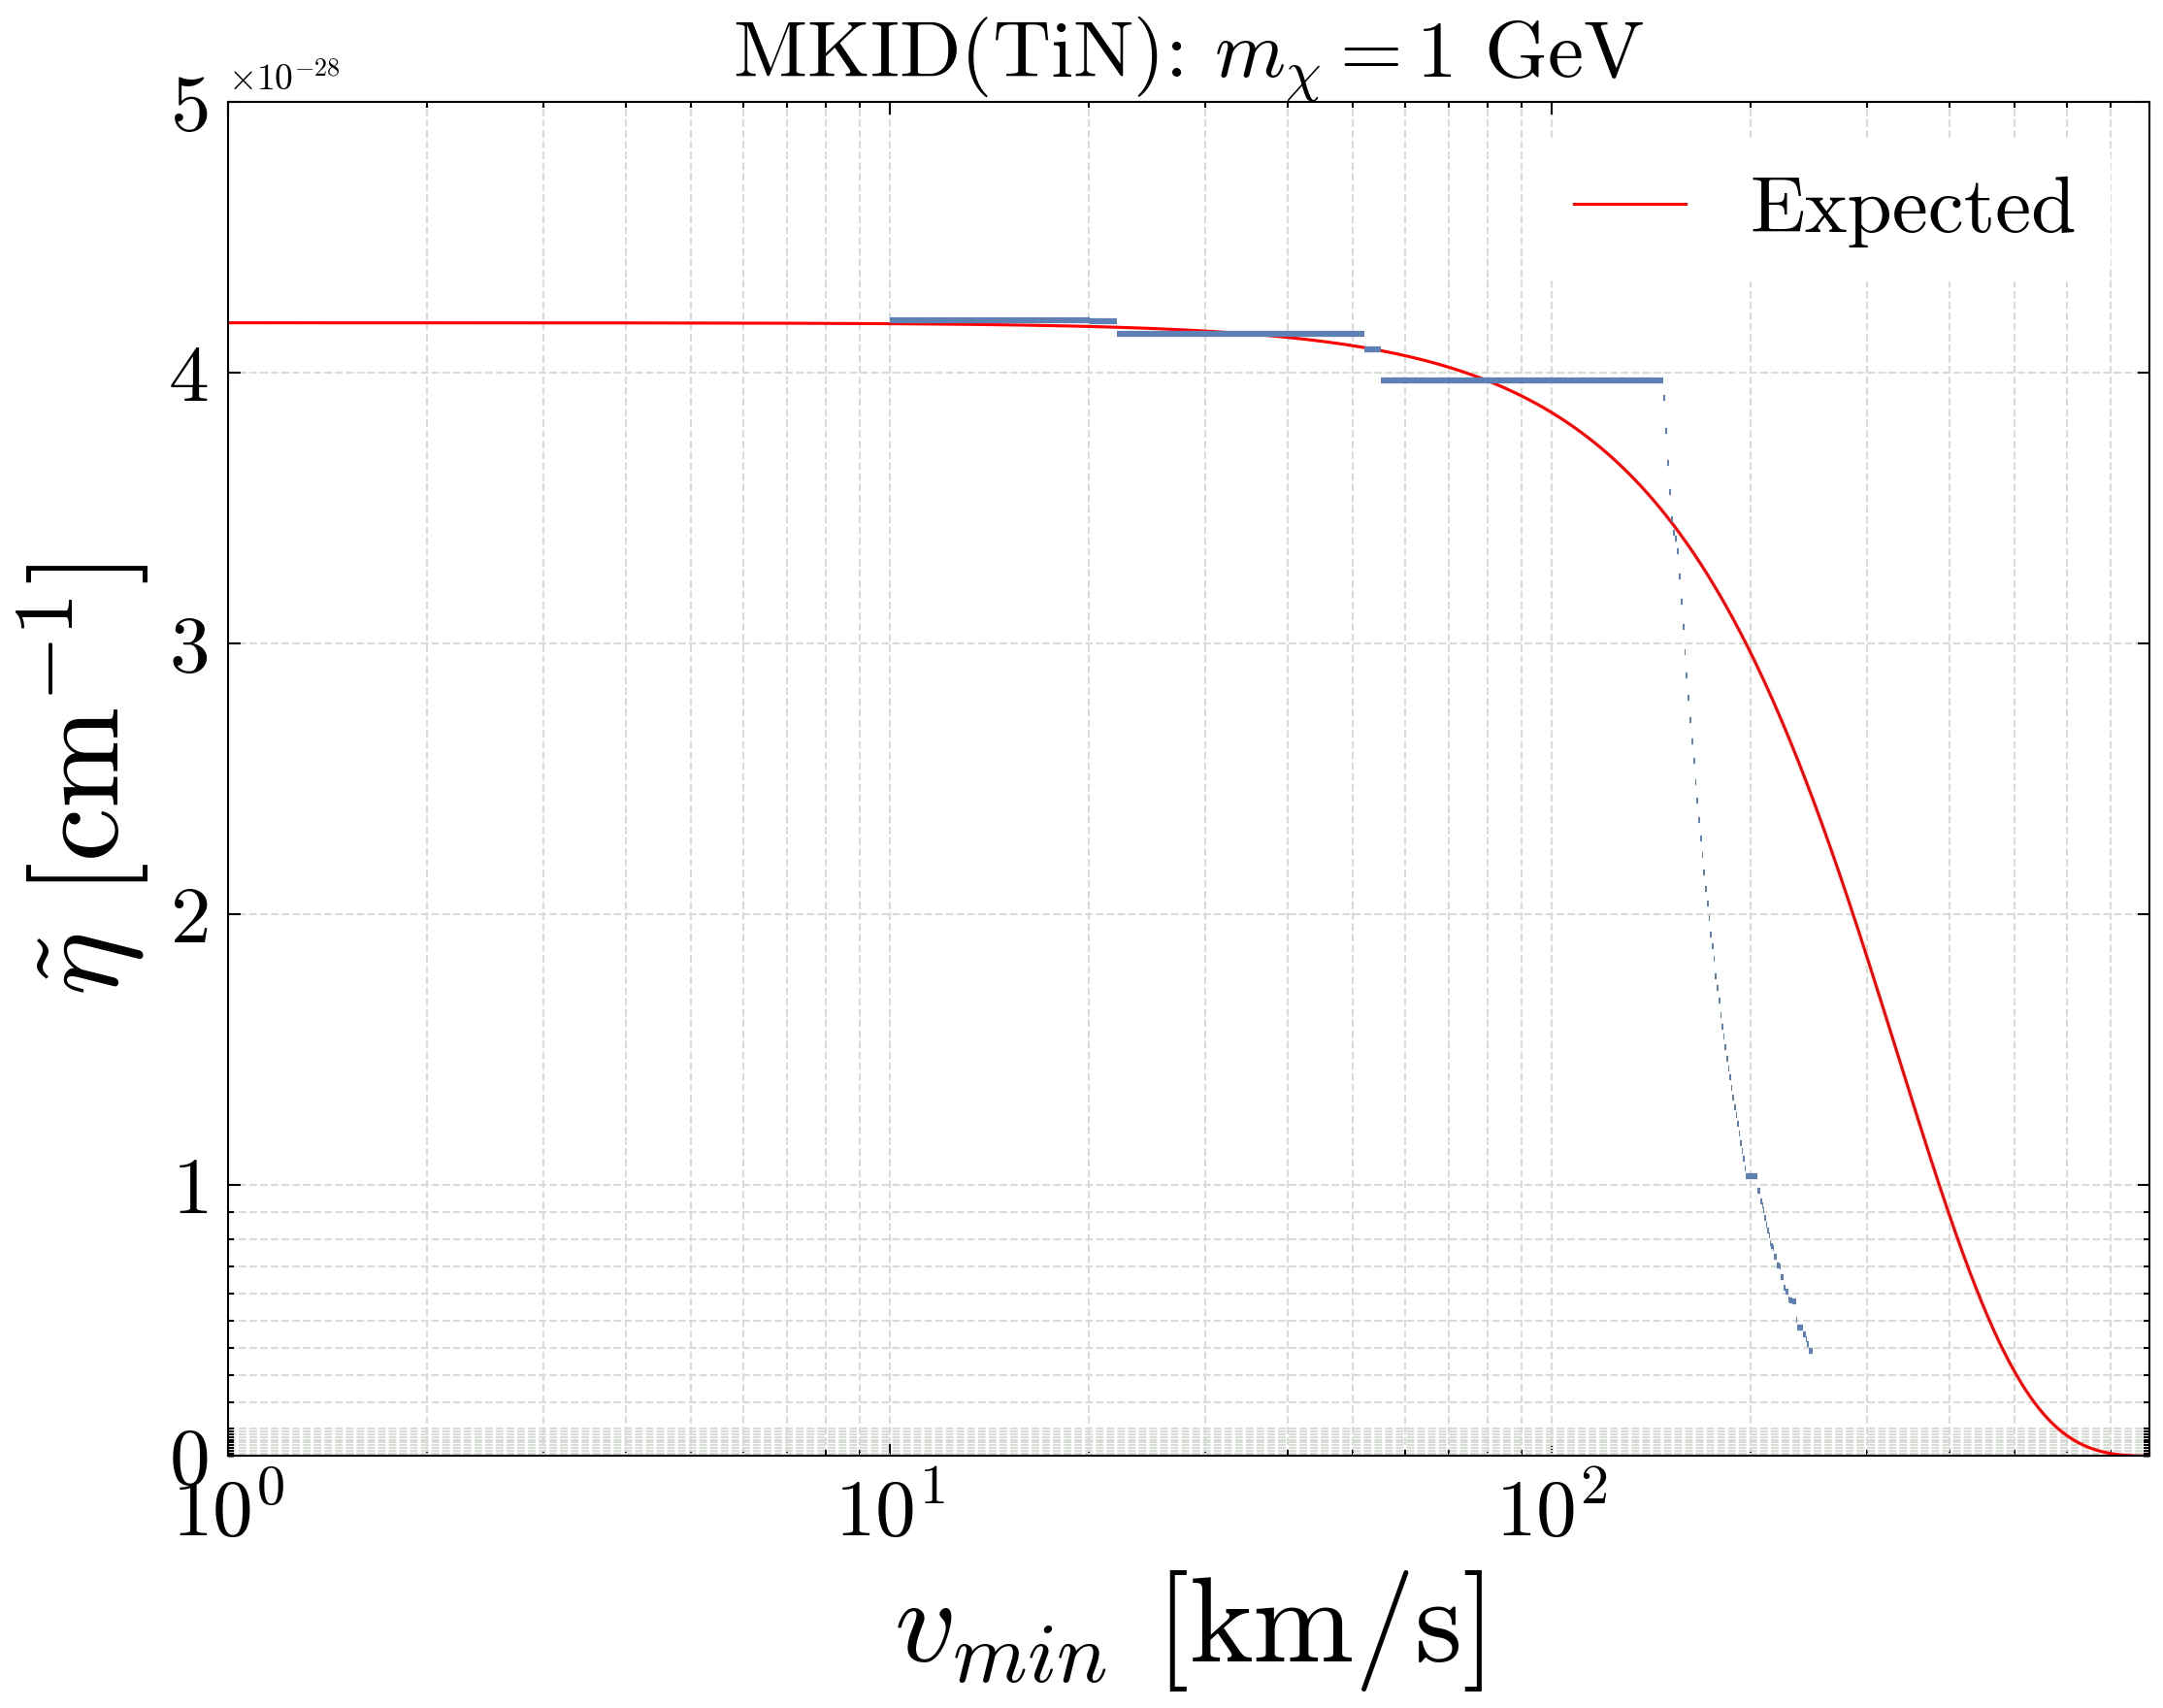

In [70]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', material = 'TiN', mass = '3', q= '0', cons1 = 1, cons2 = 9e34)#, cons1 = 2e33, cons2 = 4e62, 5.8e-3
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 5e-28)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 1$ GeV', fontsize=20)
    plt.savefig('results/MKID_1GeV_q=0_SHM.pdf')

In [11]:
np.savetxt('1GeVDisk.csv', analysis_none.fig1Solid)

In [66]:
analysis_none.CRmat@analysis_none.fig1Solid[10:248]/analysis_none.cm

array([ 5992.56228467, 21037.09126298, 30999.42679312, 40339.42580067,
       48891.38434083])

In [140]:
np.savetxt('results/events/events_MKIDSHM1000MeV.csv', 3.32323e-6 * np.array([ 6184.12158919, 21694.28893358, 31923.99189257, 41463.62912097, 50132.87543586]))

In [71]:
MKIDSHM1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDSHM1000MeV.csv', MKIDSHM1000MeV)

In [235]:
result_none.x

array([1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
       1.33405152e-03, 1.33405152e-03, 1.33405152e-03, 1.33405152e-03,
      

### Disk

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  153  |   0   | +1.9623e+27 | 1.00e+00 | 8.43e+25 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  306  |   1   | +1.8125e+27 | 7.00e+00 | 7.37e+25 | 6.38e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  459  |   3   | +3.3569e+26 | 4.90e+01 | 1.05e+25 | 6.69e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  612  |  43   | +1.3204e+26 | 4.90e+01 | 3.01e+24 | 7.83e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   5   |  765  |  95   | +4.9322e+25 | 4.90e+01 | 1.24e+24 | 7.84e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   6   |  918  |  171  | +2.2332e+25 | 4.90e+01 | 5.72e+23 | 8.65e-02 | 1.00e+00 |  1.00e-01   |   1   |
|   7   | 1071  |  247  | +1.4090e+25 | 4.90e+01 | 3.34e+23 | 7.85e-02 | 1.00e+00 |  1.00e-01   

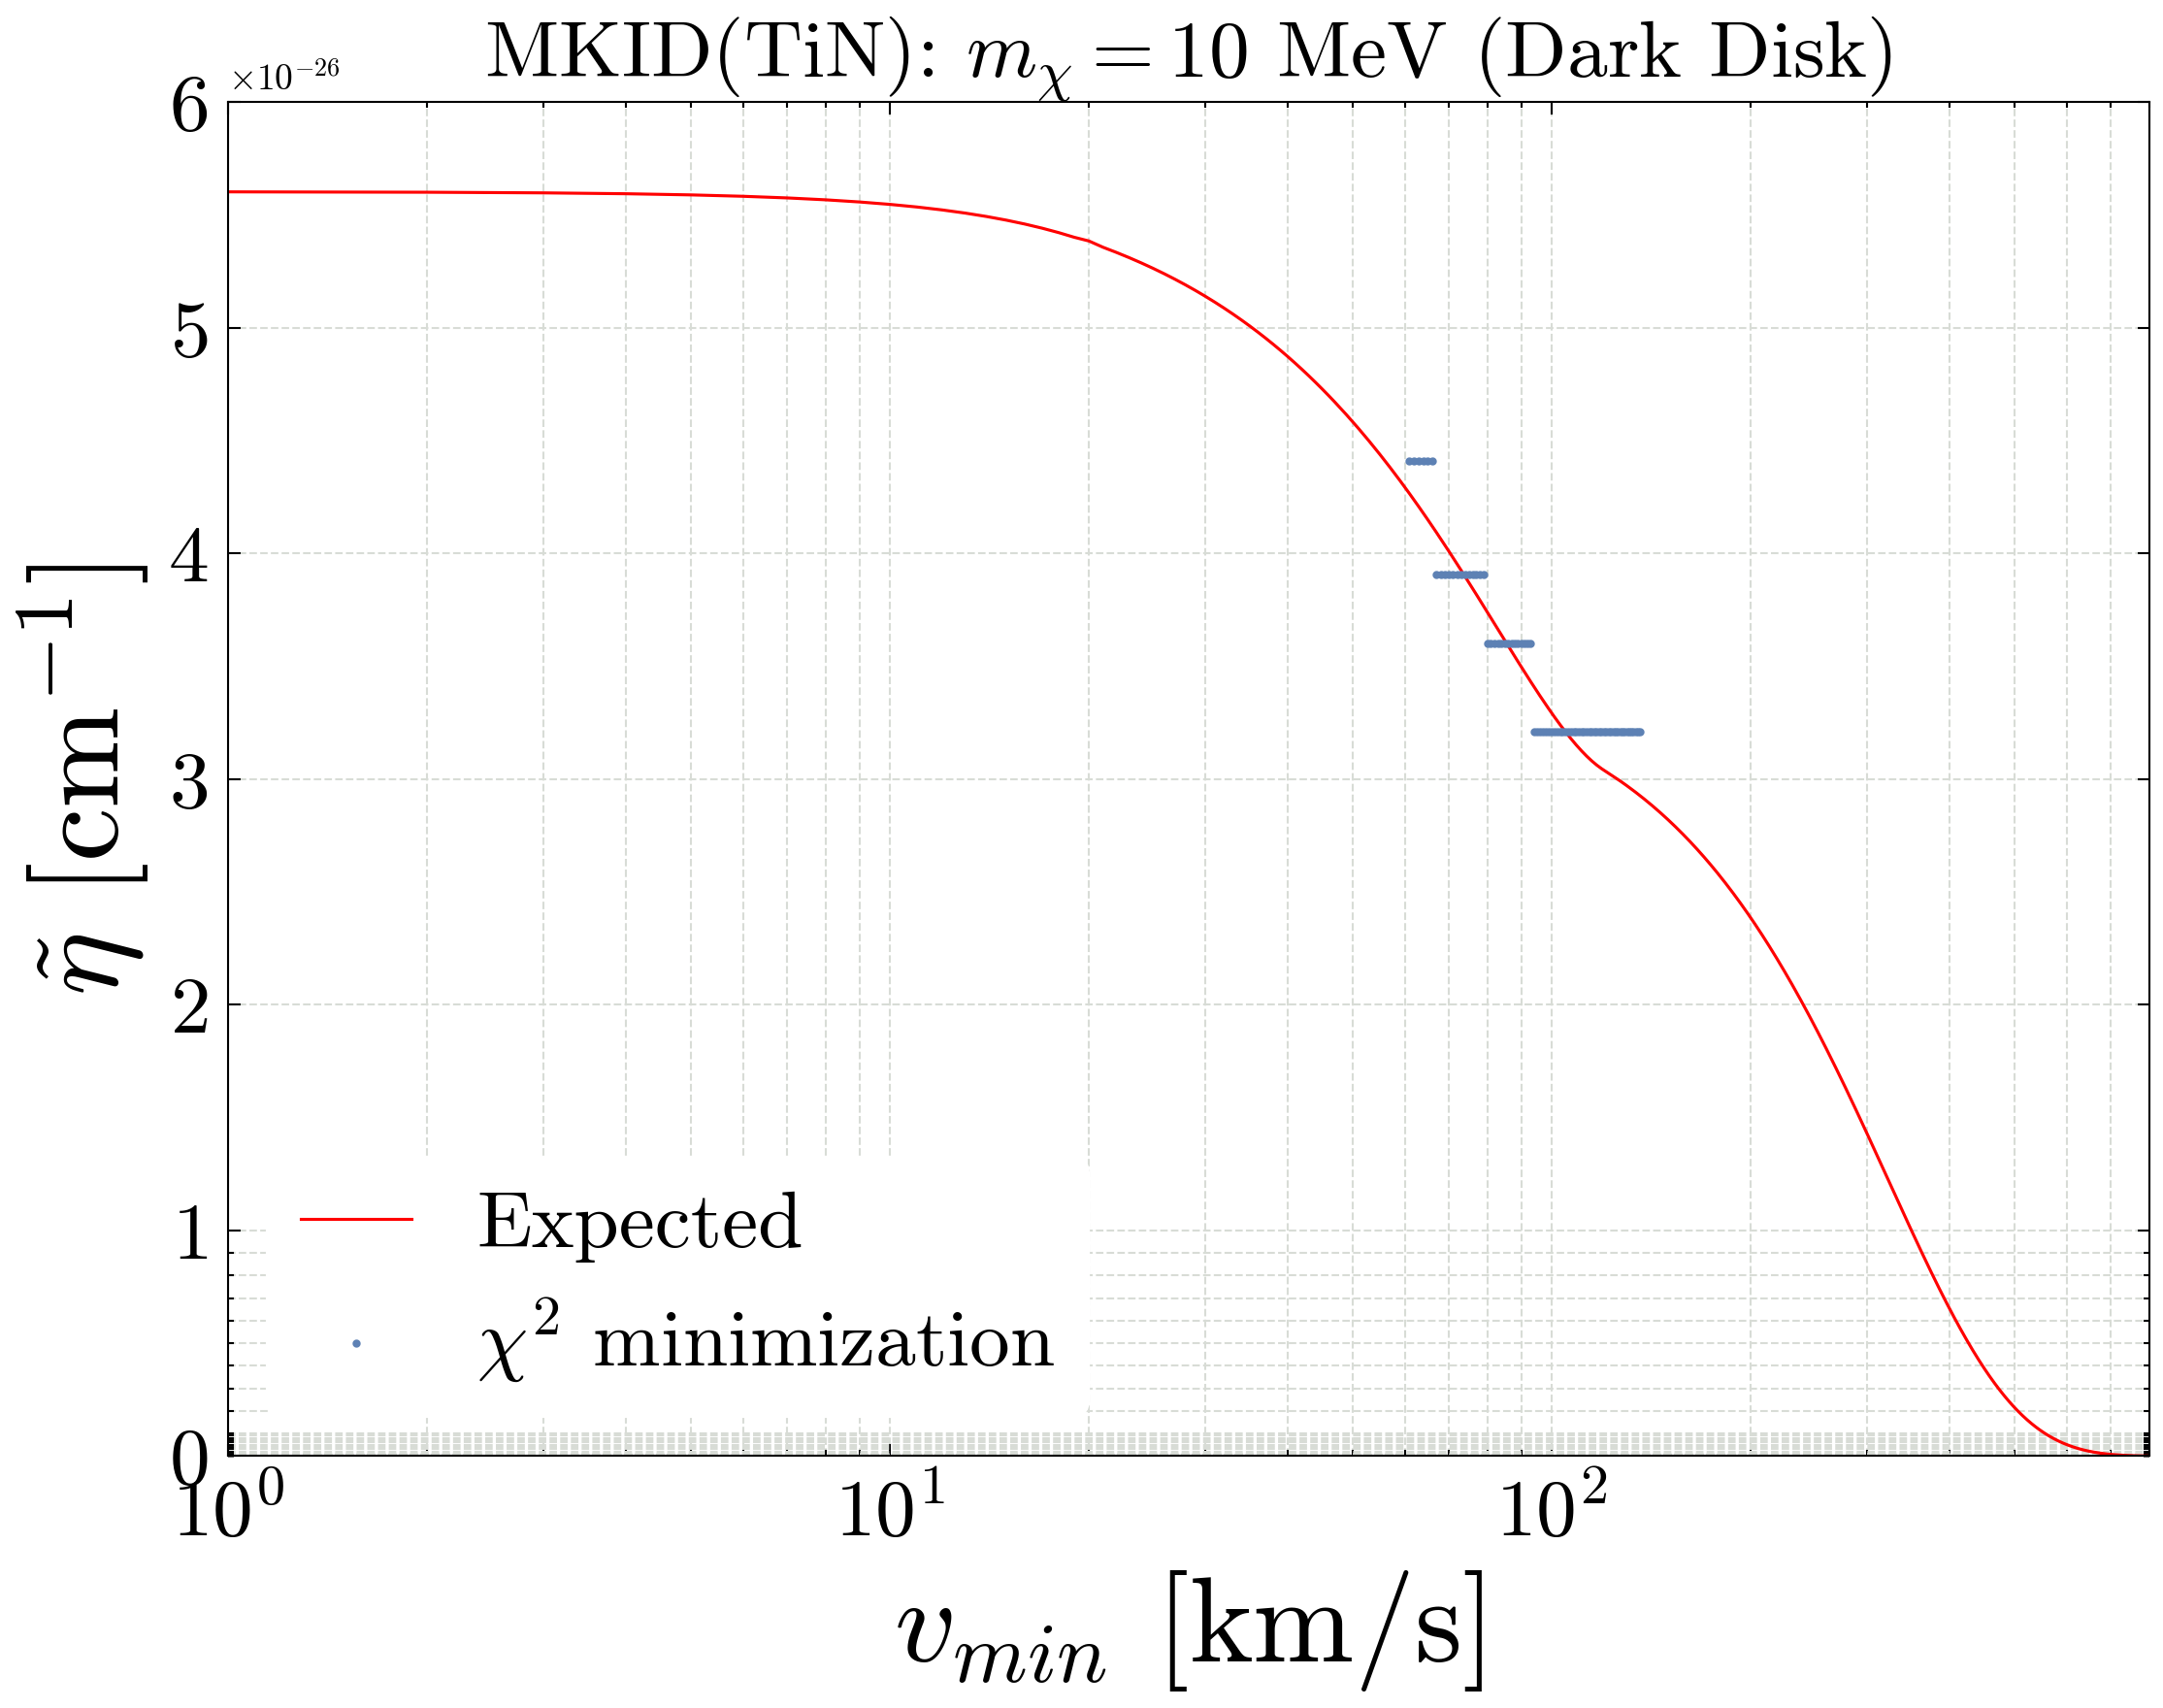

In [68]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'TiN', mass = '1', q= '0', cons1 = 8.6e-3, cons2 = 1e19)#3.8e-11
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 6e-26)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 10$ MeV (Dark Disk)', fontsize=20)
    plt.savefig('results/MKID_10MeV_q=0_Disk.pdf')

In [93]:
analysis_none.CRmat@analysis_none.fig1Solid[60:136]/analysis_none.cm

array([ 734.91517352, 2319.87795416, 3380.53850663, 4161.34001768,
       4856.93389622])

In [70]:
MKIDDisk10MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDDisk10MeV.csv', MKIDDisk10MeV)

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  195  |   0   | +1.4381e+28 | 1.00e+00 | 5.46e+26 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  390  |   1   | +1.3305e+28 | 7.00e+00 | 4.83e+26 | 4.59e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  585  |   2   | +3.5658e+27 | 4.90e+01 | 9.06e+25 | 3.67e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  780  |  46   | +1.1614e+27 | 5.13e+01 | 1.82e+25 | 3.94e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   5   |  975  |  100  | +3.9089e+26 | 5.13e+01 | 6.29e+24 | 3.82e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   6   | 1170  |  172  | +1.6397e+26 | 5.13e+01 | 2.55e+24 | 4.22e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   7   | 1365  |  269  | +8.5623e+25 | 5.13e+01 | 1.12e+24 | 4.44e-02 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  255  | 39585 | 3954  | +0.0000e+00 | 1.00e-02 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  256  | 39585 | 3960  | +0.0000e+00 | 1.00e-03 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  257  | 39585 | 3966  | +0.0000e+00 | 1.00e-04 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  258  | 39585 | 3972  | +0.0000e+00 | 1.00e-05 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  259  | 39585 | 3978  | +0.0000e+00 | 1.00e-06 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  260  | 39585 | 3984  | +0.0000e+00 | 1.00e-07 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  261  | 39585 | 3990  | +0.0000e+00 | 1.00e-08 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  262  | 39585 | 3996  | +0.0000e+00 | 1.00e-09 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  263  | 39585 | 4002  | +0.0000e+00 | 1.00e-10 | 9.67e-01 | 0.00e+00 | 1.00e+00 |  5.12e-08   |   4   |
|  264  | 39780 | 4002  | +0.0000e+00 | 1.00e+

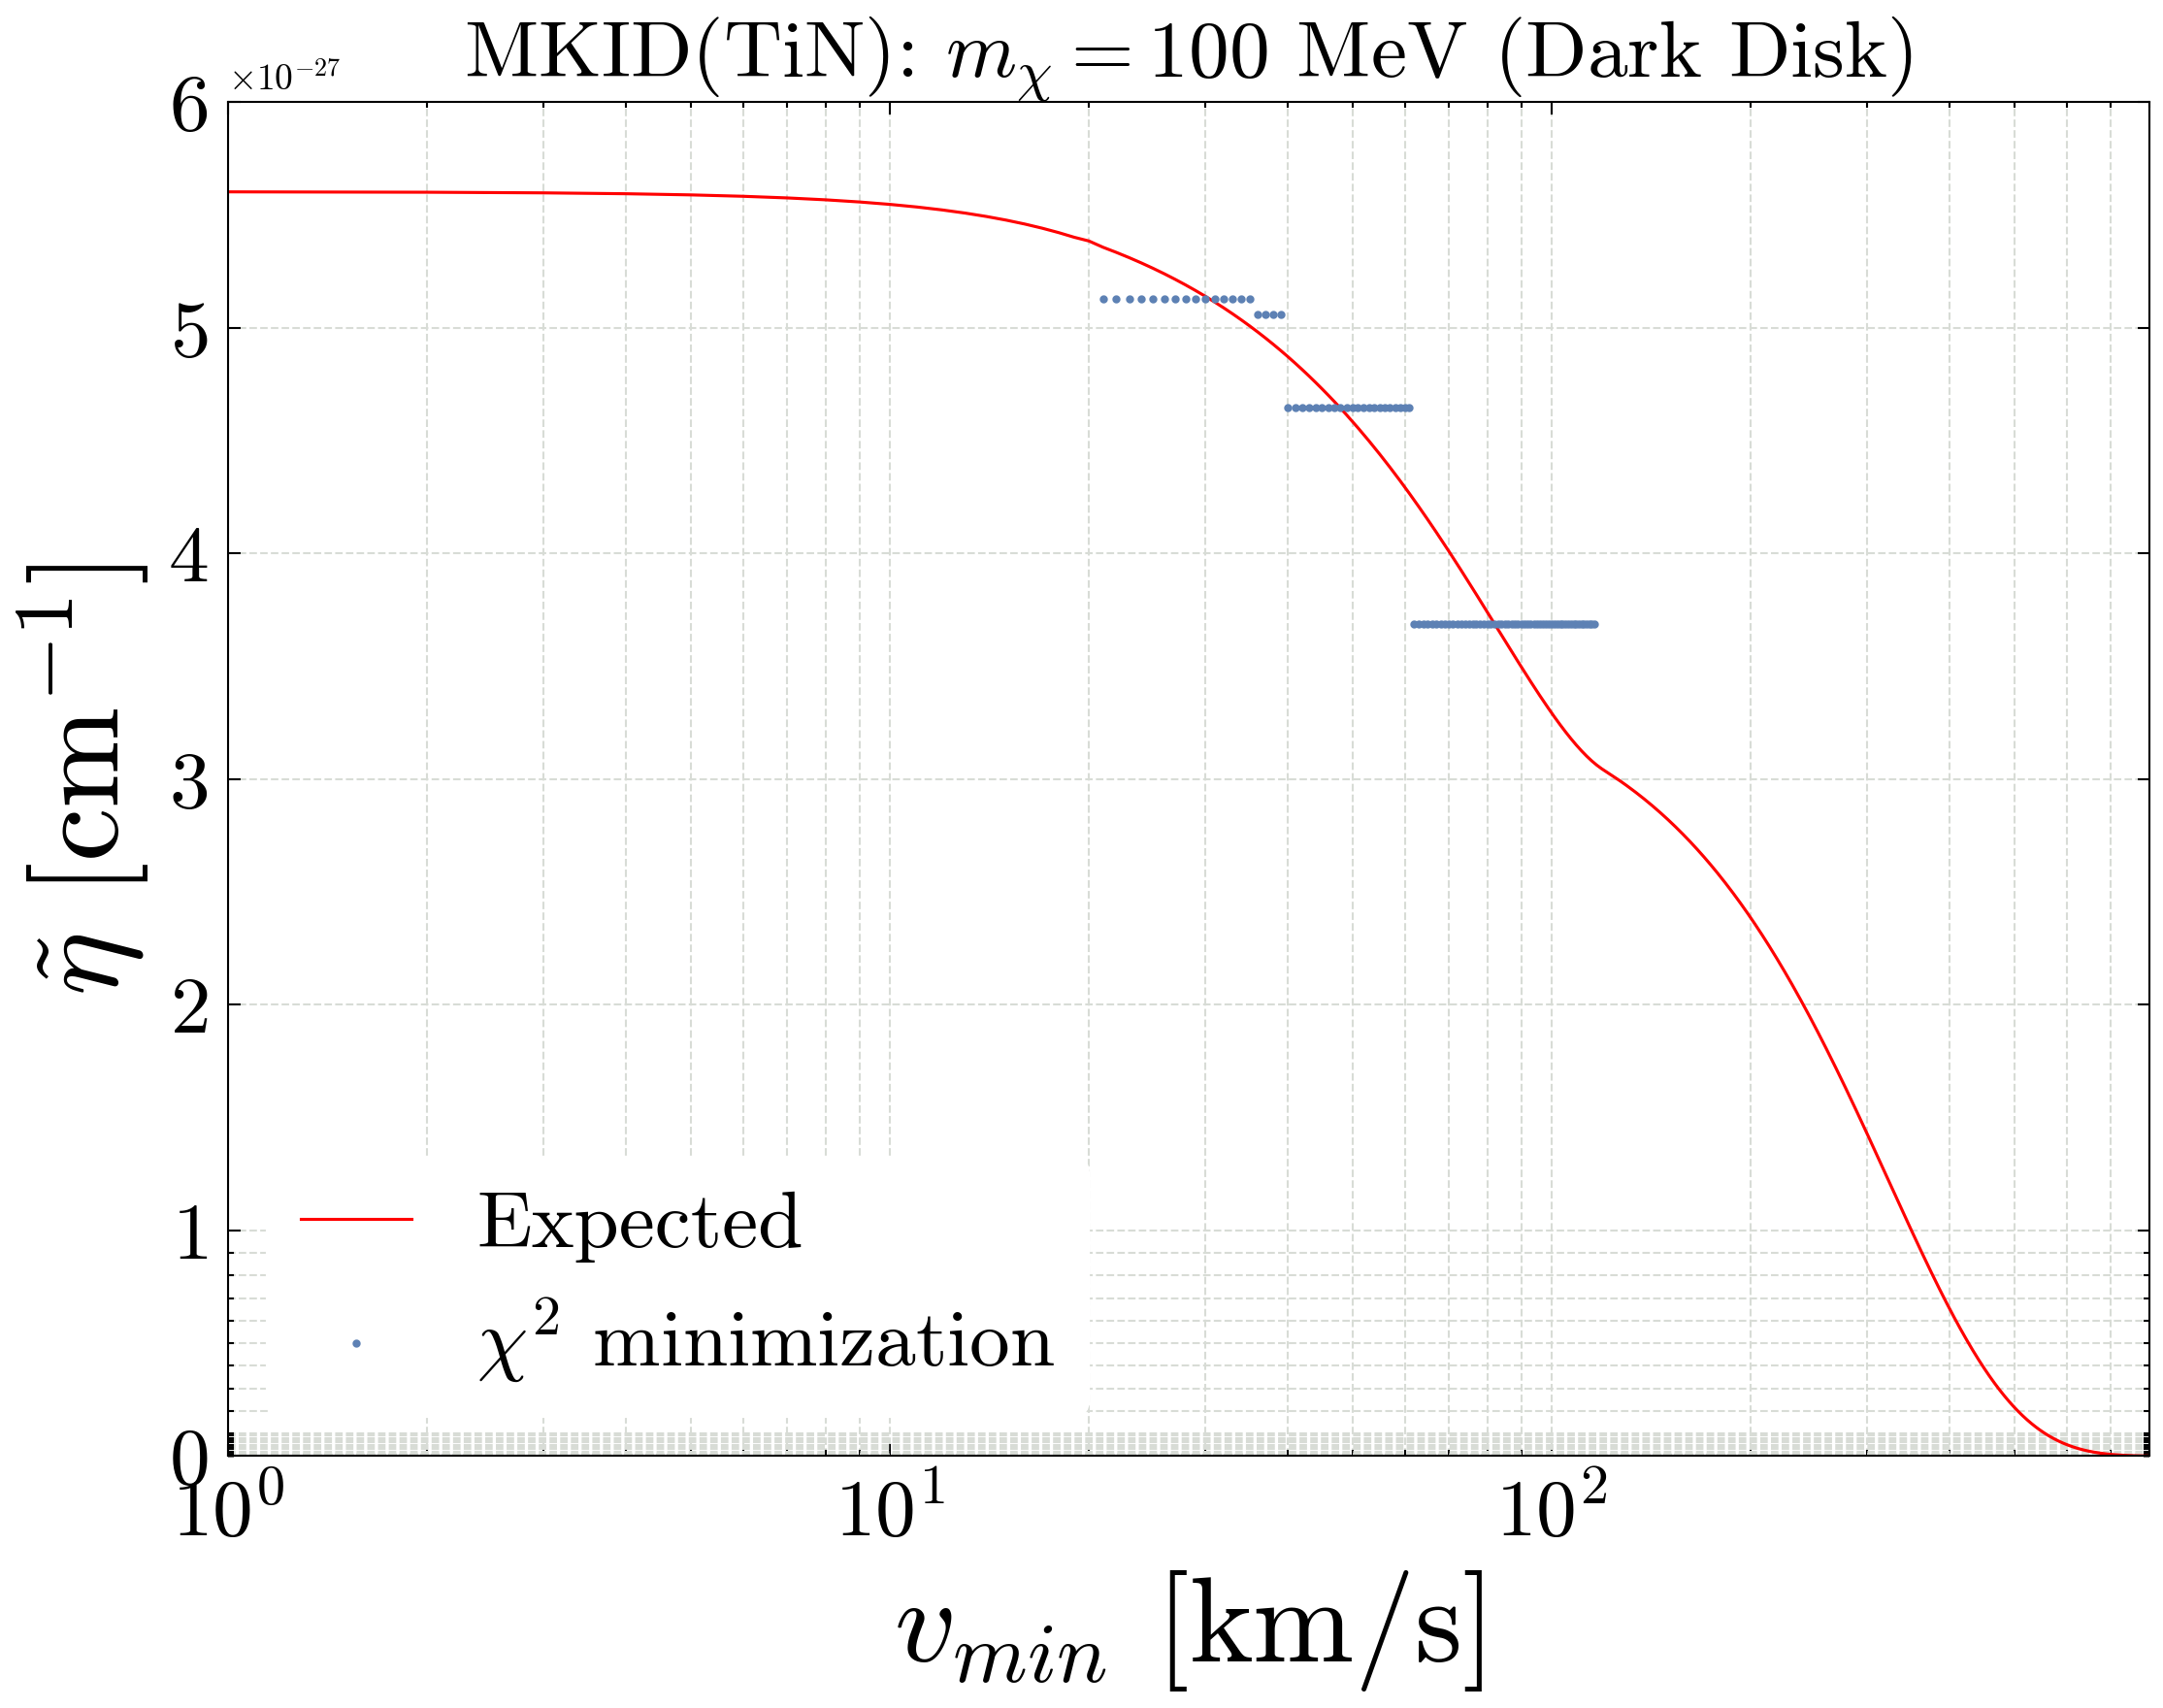

In [72]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'TiN', mass = '2', q= '0', cons1 = 8.7e-3, cons2 = 1e19)#5.8e-3
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 6e-27)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 100$ MeV (Dark Disk)', fontsize=20)
    plt.savefig('results/MKID_100MeV_q=0_Disk.pdf')

In [133]:
analysis_none.CRmat@analysis_none.fig1Solid[19:116]/analysis_none.cm

array([ 87.58425689, 285.01959957, 404.19684631, 505.8942948 ,
       589.18258183])

In [73]:
MKIDDisk100MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDDisk100MeV.csv', MKIDDisk100MeV)

In [134]:
analysis_none.CRmat@result_none.x /analysis_none.cons2 * analysis_none.cons1

array([ 87.58425689, 285.01959957, 404.19684631, 505.8942948 ,
       589.18258183])

In [135]:
analysis_none.Ratebin2

array([ 87.58425689, 285.01959957, 404.19684631, 505.8942948 ,
       589.18258183])

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  207  |   0   | +1.3462e+29 | 1.00e+00 | 5.03e+27 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  414  |   1   | +1.2447e+29 | 7.00e+00 | 4.46e+27 | 4.44e-03 | 1.00e+00 |  1.00e-01   |   2   |
|   3   |  621  |   2   | +3.6234e+28 | 4.90e+01 | 8.79e+26 | 3.45e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   |  828  |  48   | +1.1391e+28 | 5.24e+01 | 1.70e+26 | 3.81e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   5   | 1035  |  107  | +3.9134e+27 | 5.24e+01 | 6.12e+25 | 3.72e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   6   | 1242  |  185  | +1.6060e+27 | 5.24e+01 | 2.46e+25 | 3.81e-02 | 1.00e+00 |  1.00e-01   |   4   |
|   7   | 1449  |  288  | +8.3971e+26 | 5.24e+01 | 1.07e+25 | 3.77e-02 | 1.00e+00 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  225  | 52785 | 4749  | +0.0000e+00 | 1.00e-02 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  226  | 53199 | 4754  | +0.0000e+00 | 1.00e-03 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  227  | 53613 | 4759  | +0.0000e+00 | 1.00e-04 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  228  | 54027 | 4764  | +0.0000e+00 | 1.00e-05 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  229  | 54441 | 4769  | +0.0000e+00 | 1.00e-06 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  230  | 54855 | 4774  | +0.0000e+00 | 1.00e-07 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  231  | 55269 | 4779  | +0.0000e+00 | 1.00e-08 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  232  | 55683 | 4784  | +0.0000e+00 | 1.00e-09 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  233  | 56097 | 4789  | +0.0000e+00 | 1.00e-10 | 2.30e-02 | 0.00e+00 | 1.00e+00 |  1.60e-04   |   4   |
|  234  | 56304 | 4789  | +0.0000e+00 | 1.00e+

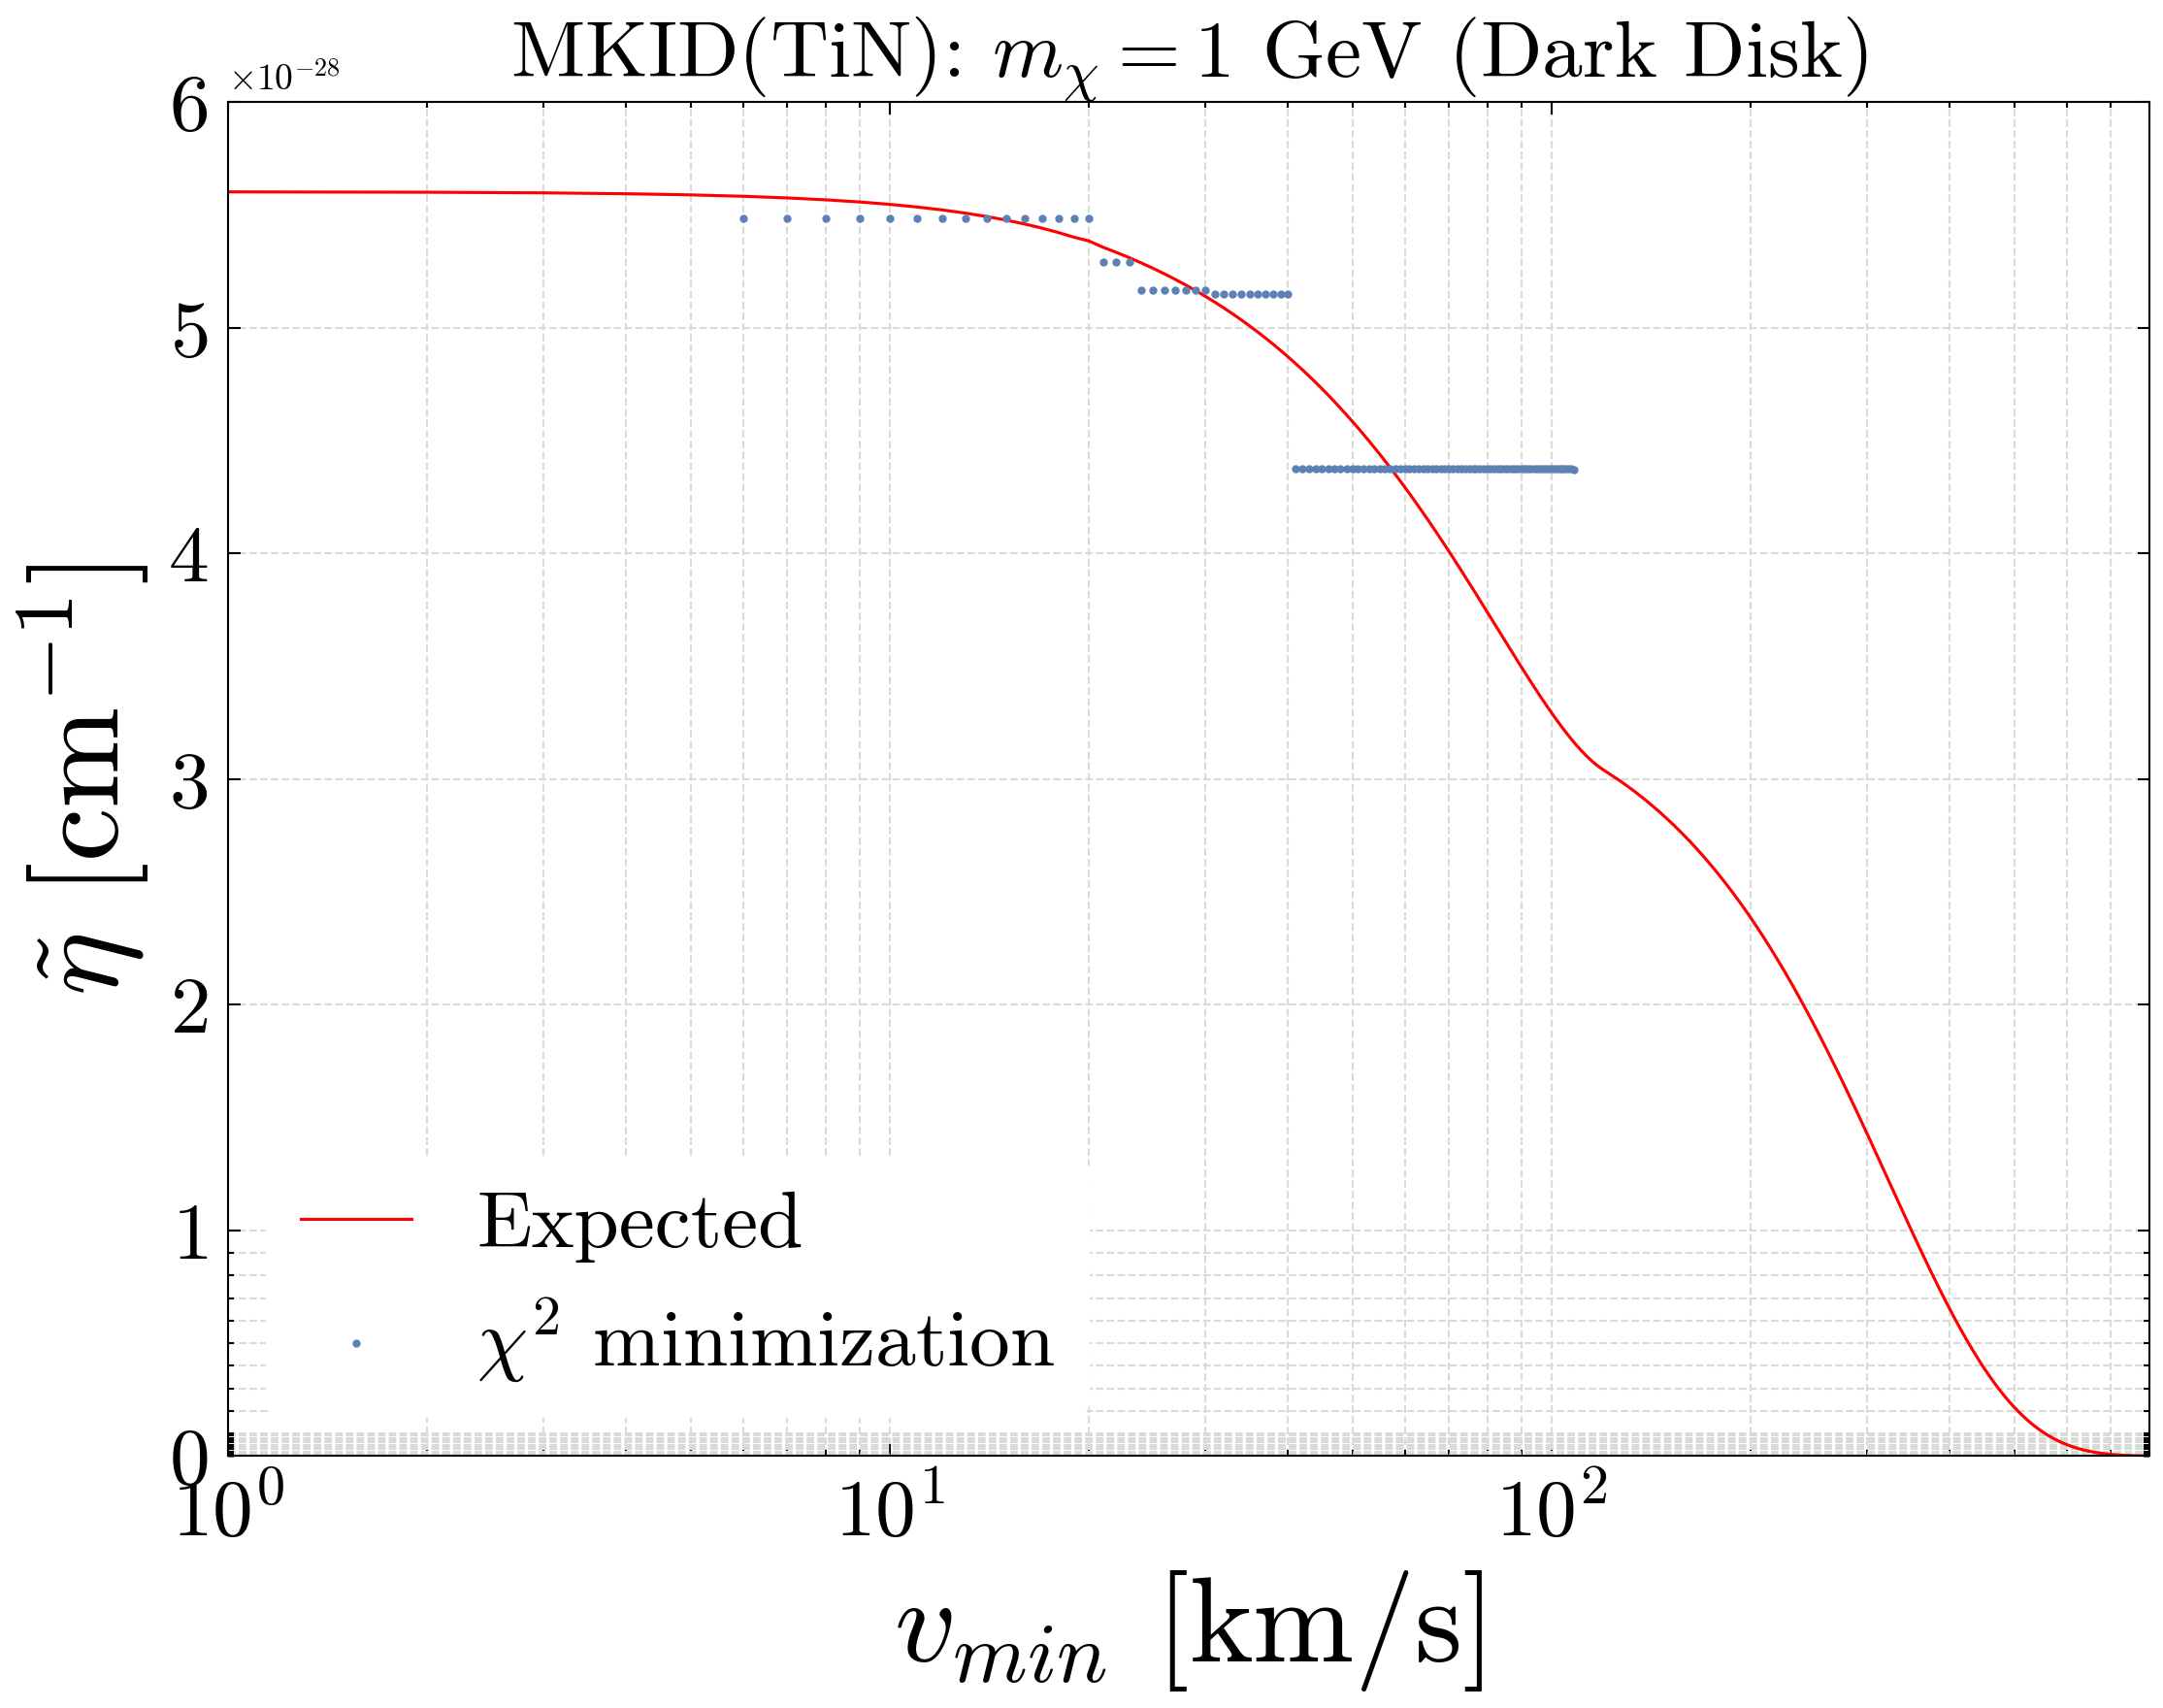

In [14]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Disk', material = 'TiN', mass = '3', q= '0', cons1 = 8.7e-3, cons2 = 1.0e19)#, cons1 = 8.50000001e-3, cons2 = 1.0e18
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(4e-21, 5e-21)
    plt.ylim(0, 6e-28)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 1$ GeV (Dark Disk)', fontsize=20)
    plt.savefig('results/MKID_1GeV_q=0_Disk.pdf')

In [227]:
analysis_none.CRmat@analysis_none.fig1Solid[5:108]/analysis_none.cm

array([ 9.0487686 , 29.65127274, 42.35867468, 53.31798571, 62.36909046])

In [15]:
MKIDDisk1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDDisk1000MeV.csv', MKIDDisk1000MeV)

### Bound

--- Running main optimization for background 'none' ---
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  | penalty  |barrier param|CG stop|
|-------|-------|-------|-------------|----------|----------|----------|----------|-------------|-------|
|   1   |  477  |   0   | +1.3258e+46 | 1.00e+00 | 4.35e+35 | 0.00e+00 | 1.00e+00 |  1.00e-01   |   0   |
|   2   |  954  |   1   | +1.3258e+46 | 2.00e+00 | 4.06e+35 | 1.64e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   3   | 1431  |   3   | +1.3258e+46 | 1.40e+01 | 4.60e+35 | 3.35e-02 | 1.00e+00 |  1.00e-01   |   2   |
|   4   | 1908  |  55   | +1.3258e+46 | 8.73e+01 | 4.83e+35 | 1.90e-01 | 1.00e+00 |  1.00e-01   |   4   |
|   5   | 2385  |  60   | +1.3258e+46 | 3.79e+02 | 4.90e+35 | 9.95e-01 | 1.00e+00 |  1.00e-01   |   2   |
|   6   | 2862  |  125  | +1.3258e+46 | 5.43e+02 | 4.92e+35 | 1.80e+00 | 1.00e+00 |  1.00e-01   |   2   |
|   7   | 3339  |  363  | +1.3258e+46 | 5.43e+02 | 4.87e+35 | 1.54e+00 | 1.23e+37 |  1.00e-01   

/Users/koichiro/miniforge3/envs/python313/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  855  |411174 | 38579 | +2.0858e+14 | 2.74e-03 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  856  |412128 | 38602 | +2.0858e+14 | 1.17e-03 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  857  |413082 | 38624 | +2.0858e+14 | 5.22e-04 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  858  |414036 | 38647 | +2.0858e+14 | 2.17e-04 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  859  |414990 | 38670 | +2.0858e+14 | 7.43e-05 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  860  |415944 | 38692 | +2.0858e+14 | 3.59e-05 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  861  |416898 | 38715 | +2.0858e+14 | 1.80e-05 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  862  |417852 | 38737 | +2.0858e+14 | 8.98e-06 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  863  |418806 | 38743 | +2.0858e+14 | 4.27e-06 | 6.29e+19 | 0.00e+00 | 5.21e+39 |  1.00e-01   |   2   |
|  864  |419760 | 38747 | +1.7524e+14 | 4.27e-

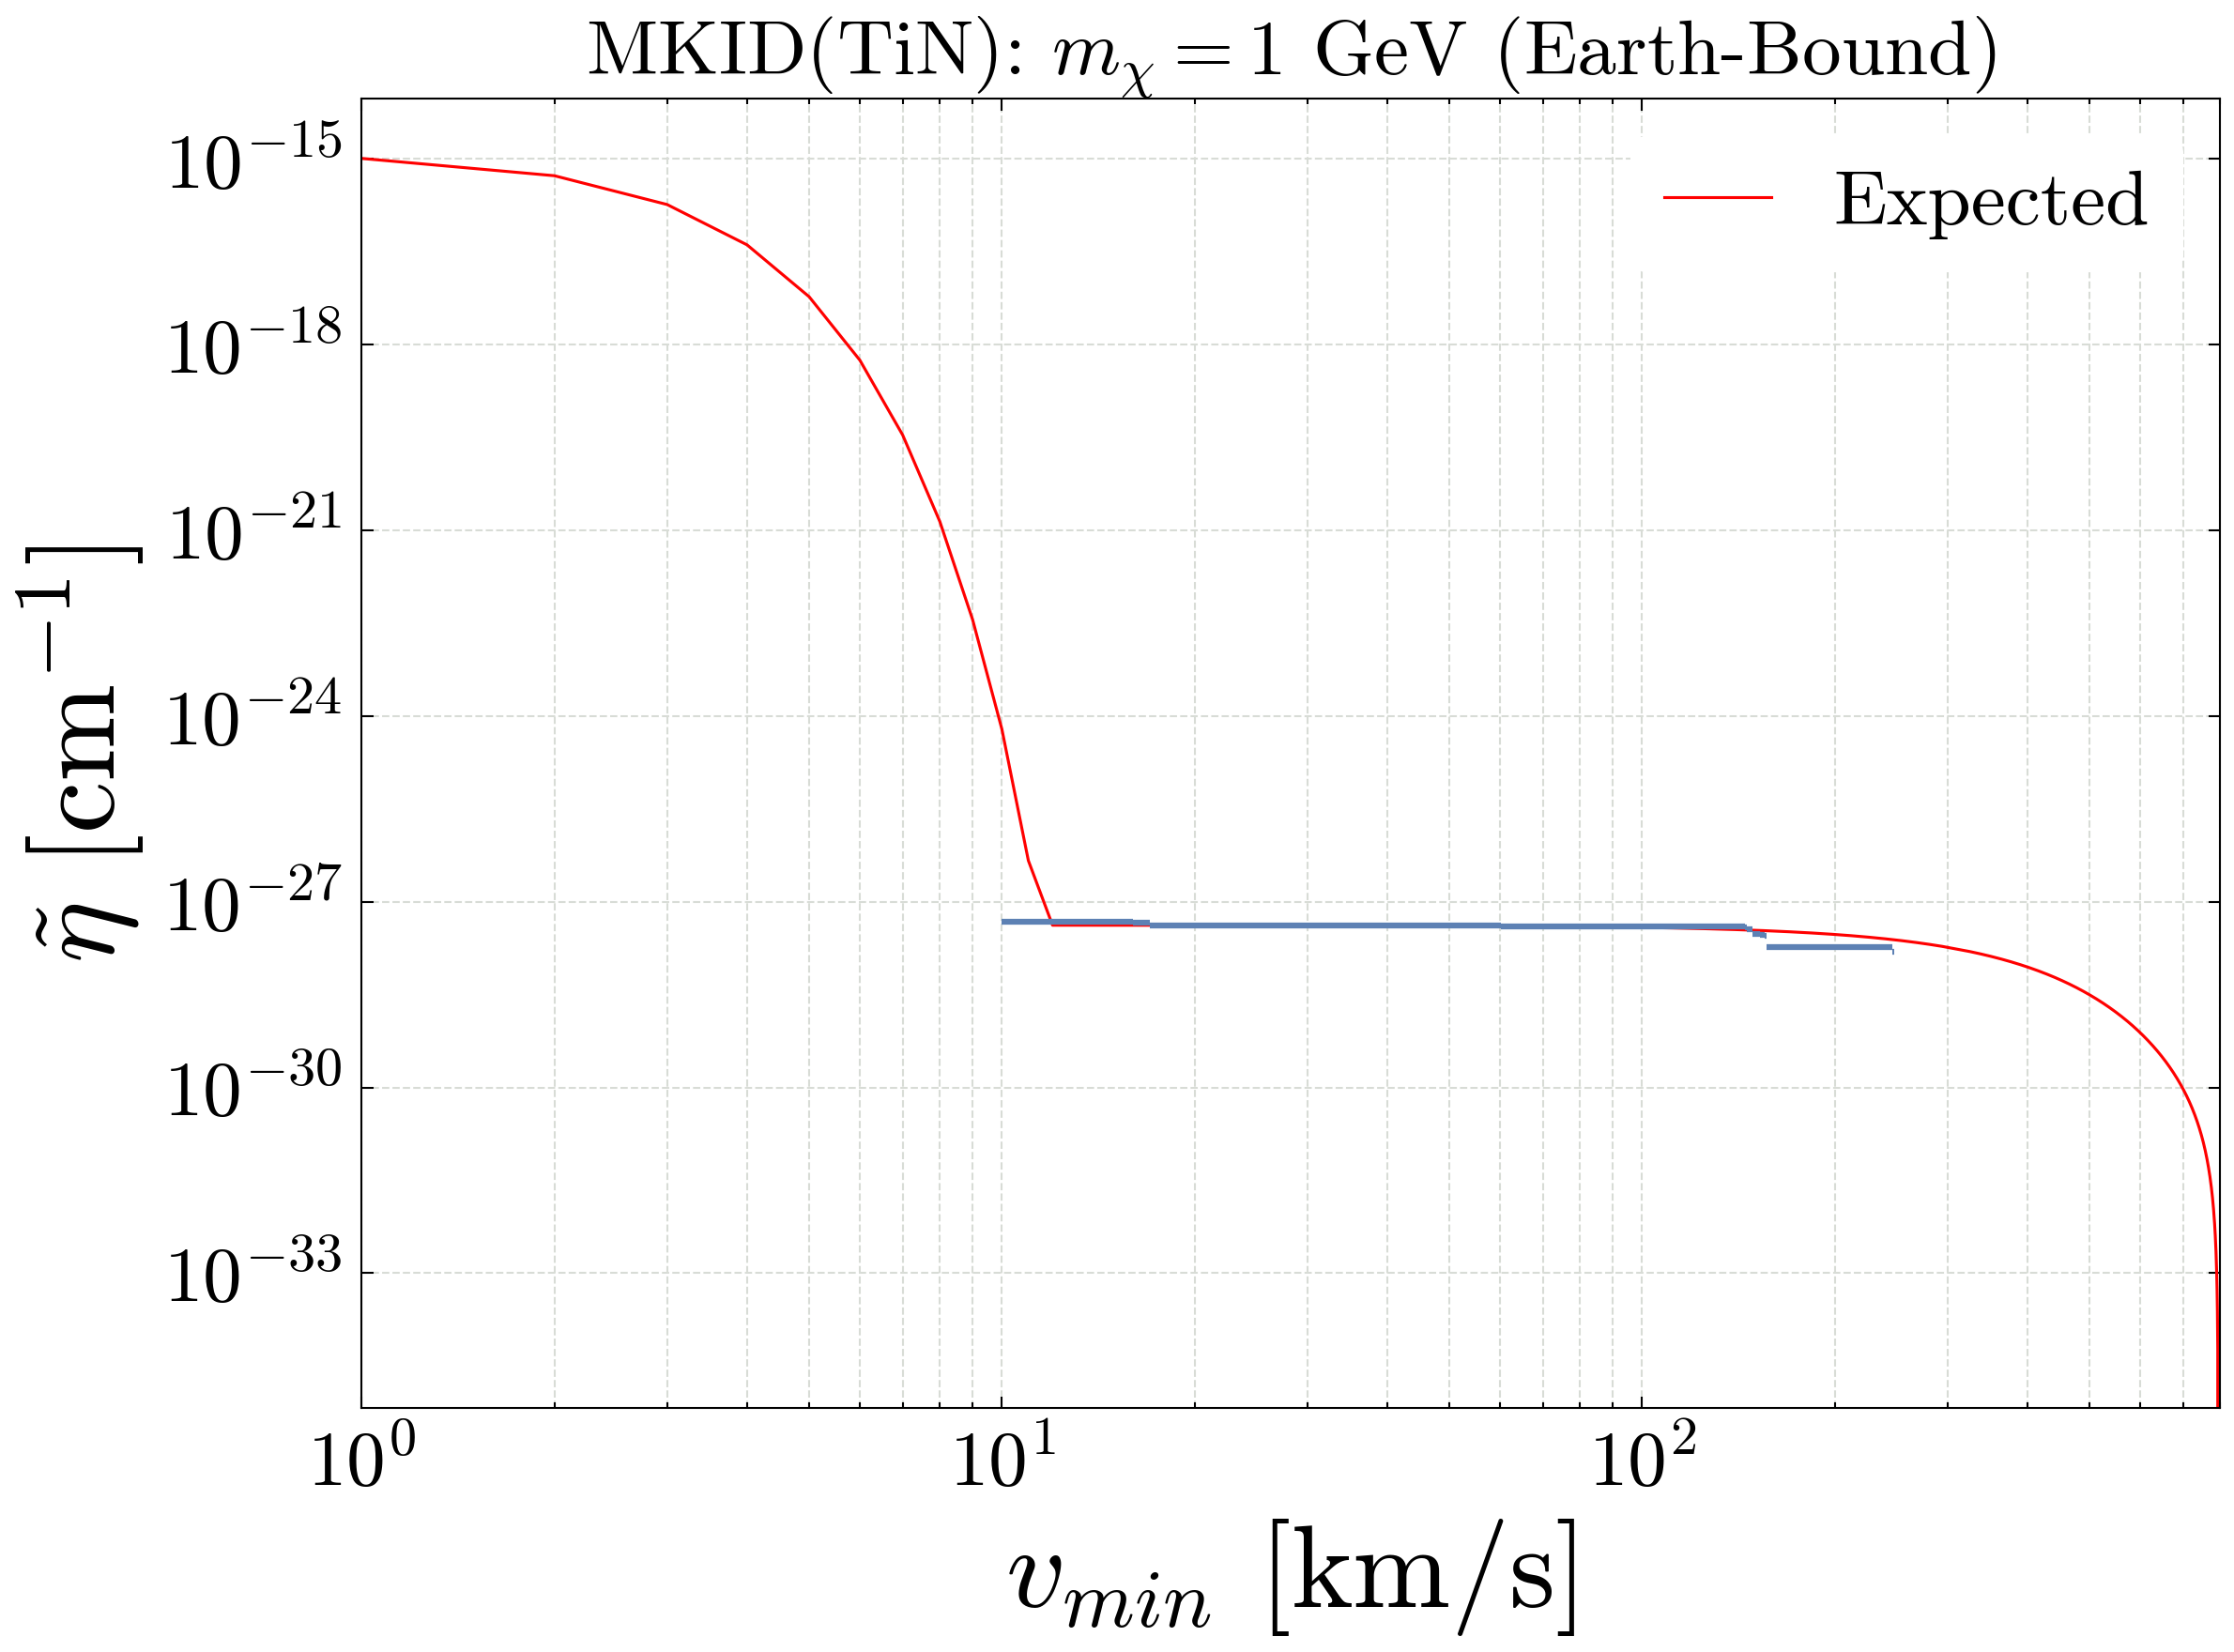

In [82]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from neutrino_analysis_refined import NeutrinoAnalysis
#from neutrino_analysis import NeutrinoAnalysis, plot_flux_with_uncertainty_bands
if __name__ == '__main__':
    # This block defines the main workflow of the script.
    # It will only run when the script is executed directly.
    # 1. Initialize the analysis class with a specific background scenario
    analysis_none = NeutrinoAnalysis(background_scenario='none', eta = 'Bound', material = 'TiN', mass = '3', q= '0', cons1 = 1, cons2 = 9e40)#, cons1 = 1e33, cons2 = 4e61, 1e-4, 1e10
    # 2. Run the main optimization.
    print("--- Running main optimization for background 'none' ---")
    result_none = analysis_none.optimize(analysis_none.data_vector)
   # print("Free fit success:", result_none.success)
    #print("Free fit message:", result_none.message)
    #print("Free fit iterations:", result_none.nit)
    
   # print("\nOptimization Complete.")
   # print(f"Minimum chi-squared: {1e3 * analysis_none.gram * analysis_none.yr * result_none.fun / analysis_none.c}")
    
    # 3. Plot the primary result: the optimized flux vs. theory.
    analysis_none.plot_eta_comparison()
    #plt.ylim(1e-29, 1e-13)
    plt.rcParams["font.size"] = 10
    plt.rcParams['figure.dpi'] = "300"

    plt.yscale('log')

    #plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=40))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tick_params(axis='both', which='minor', labelsize=20)
    plt.title(r'MKID(TiN): $m_\chi = 1$ GeV (Earth-Bound)', fontsize=20)
    #plt.savefig('results/MKID_1GeV_q=0_Bound.pdf')

In [83]:
MKIDBound1000MeV = result_none.x /analysis_none.cons2 * analysis_none.cons1 * analysis_none.cm
np.savetxt('results/data/MKIDBound1000MeV.csv', MKIDBound1000MeV)

In [96]:
len(analysis_none.CRmat[0])

199

In [94]:
boundHalo(np.linspace(6, 108, 200))

array([5.94064067e-32, 3.23982585e-32, 6.55897708e-33, 3.39570978e-33,
       5.16876689e-34, 2.54838315e-34, 2.90693399e-35, 1.36628818e-35,
       1.15094692e-36, 5.06556893e-37, 1.75808421e-38, 7.27984079e-39,
       8.54548621e-42, 8.54453032e-42, 8.54354824e-42, 8.54251602e-42,
       8.54145388e-42, 8.54034536e-42, 8.53920319e-42, 8.53801841e-42,
       8.53679626e-42, 8.53553525e-42, 8.53423315e-42, 8.53289595e-42,
       8.53151396e-42, 8.53010062e-42, 8.52863877e-42, 8.52714932e-42,
       8.52560768e-42, 8.52404218e-42, 8.52242078e-42, 8.52077927e-42,
       8.51907819e-42, 8.51736072e-42, 8.51558001e-42, 8.51378664e-42,
       8.51192635e-42, 8.51005714e-42, 8.50811734e-42, 8.50617235e-42,
       8.50415311e-42, 8.50213016e-42, 8.50003378e-42, 8.49793147e-42,
       8.49575949e-42, 8.49357789e-42, 8.49133038e-42, 8.48906956e-42,
       8.48674661e-42, 8.48440665e-42, 8.48200831e-42, 8.47958930e-42,
       8.47711565e-42, 8.47461767e-42, 8.47206880e-42, 8.46949193e-42,
      

In [97]:
analysis_none.CRmat@boundHalo(np.linspace(6, 108, 199))

array([6.21801728e+00, 8.53020774e-01, 5.67989290e-03, 1.51210382e-04,
       6.90130656e-05])

In [73]:
analysis_none.CRmat@analysis_none.fig1Solid[10:248]/analysis_none.cm

array([ 6041.21901789, 21037.09126298, 30999.42679312, 40339.42580067,
       48891.38434083])

In [132]:
np.savetxt('results/events/events_MKIDBound1000MeV.csv', 3.32323e-6 * np.array([17920.01087563, 21694.28893358, 31923.99189257, 41463.62912097, 50132.87543586]))